# Study 19 — Cricket as a Spatial Game: Fielding Positions

Cricket fielding positions describe where players stand using familiar names such as slip, gully, point, cover, mid-off, mid-on, square leg, fine leg and third man.

Those names already contain spatial information.

In this study, we will turn that traditional description of a field into a simple data representation:

$$
\text{fielding position} \rightarrow (x, y)
$$

Once positions have coordinates, we can begin to measure the structure of a field: where fielders are located, how far apart they are, what angles they occupy around the batter, and how different field settings distribute players across space.

The central question is:

> **How can a traditional cricket field, described using named positions, be turned into data that can be measured and analysed?**

We will begin with a deliberately simplified representation of the field rather than attempting to model the full game.

## A coordinate system for the field

Before we can measure fielding positions, we need to define what our coordinates mean.

We will use the **centre of the striker's wicket** as the origin:

$$
(0,0)
$$

This gives us a fixed physical reference point that does not depend on the striker's stance or position at the crease.

The field will be viewed from above, with the **bowler's end** at the top of the diagram.

Cricket already provides the important directional distinction between the **off side** and the **leg side**. We will retain that terminology rather than replacing it with our own labels.

The coordinate system itself is an analytical convention that we must define.

We will use:

- positive $y$ in the direction from the striker's wicket towards the bowler's end;
- negative $y$ in the direction behind the striker's wicket;
- positive $x$ towards the striker's off side;
- negative $x$ towards the striker's leg side.

Therefore, viewed from above:

$$
\begin{array}{c}
\text{bowler's end} \\
\uparrow \\
+y \\
\\
\text{leg side}
\quad \longleftarrow \quad
(0,0)
\quad \longrightarrow \quad
\text{off side} \\
\\
-y \\
\downarrow \\
\text{behind the striker's wicket}
\end{array}
$$

Distances will be measured in **metres**, so that the coordinates retain a direct physical interpretation.

This is our analytical coordinate convention rather than an official cricket coordinate standard. Wherever possible, however, it is anchored to established cricket terminology and physical features of the field.

The named fielding positions require another modelling decision. Terms such as **slip**, **gully**, **point**, **cover** and **fine leg** describe recognised areas or roles rather than one universally fixed point on the field. A fielder can stand deeper, shallower, squarer or straighter while still occupying the same broadly recognised position.

For this study, we will therefore assign each named fielding position a **representative coordinate**.

Those coordinates will be part of our model, not official definitions of where a fielder must stand.

This gives us a consistent spatial representation that we can measure while keeping the distinction clear between established cricket terminology and assumptions introduced for the analysis.

## From named positions to representative coordinates

We now have a coordinate system, but cricket fielding positions are still described using names rather than numbers.

The next step is to translate a small set of familiar positions into representative coordinates:

$$
\text{position name}
\rightarrow
(x,y)
$$

We will begin with:

- first slip;
- gully;
- point;
- cover;
- mid-off;
- mid-on;
- square leg;
- fine leg;
- third man.

This is not yet intended to represent a complete fielding XI. The purpose is first to establish how named cricket positions can be stored and plotted spatially.

There is no single fixed coordinate for any of these positions. Their exact locations vary with the field setting, bowler, striker and match situation.

We will therefore choose **illustrative representative locations**, measured in metres from the centre of the striker's wicket.

The important distinction is:

> The **position names come from cricket**; the **coordinates are assumptions in our spatial model**.

Once those assumptions are explicit, we can inspect them visually and change them whenever a different field setting requires it.

In [1]:
import pandas as pd

# Representative fielding locations for this study.
#
# Coordinates are measured in metres from the centre of the striker's wicket:
#   x > 0  -> off side
#   x < 0  -> leg side
#   y > 0  -> towards the bowler's end
#   y < 0  -> behind the striker's wicket
#
# These coordinates are modelling assumptions, not official definitions of
# where each named fielding position must be located.

fielding_positions = [
    {"position": "Wicket-keeper", "x_m": 0,   "y_m": -3},
    {"position": "First slip",    "x_m": 3,   "y_m": -5},
    {"position": "Gully",         "x_m": 12,  "y_m": -8},
    {"position": "Point",         "x_m": 22,  "y_m": 0},
    {"position": "Cover",         "x_m": 28,  "y_m": 18},
    {"position": "Mid-off",       "x_m": 12,  "y_m": 28},
    {"position": "Mid-on",        "x_m": -10, "y_m": 28},
    {"position": "Square leg",    "x_m": -22, "y_m": 0},
    {"position": "Fine leg",      "x_m": -24, "y_m": -25},
    {"position": "Third man",     "x_m": 30,  "y_m": -28},
]

field = pd.DataFrame(fielding_positions)

field

,position,x_m,y_m
0,Wicket-keeper,0,-3
1,First slip,3,-5
2,Gully,12,-8
3,Point,22,0
4,Cover,28,18
5,Mid-off,12,28
6,Mid-on,-10,28
7,Square leg,-22,0
8,Fine leg,-24,-25
9,Third man,30,-28


## Plotting the fielding positions

A table tells us the coordinates, but it does not make the spatial structure of the field easy to see.

We will now plot the representative positions using the same orientation as our coordinate system:

- the **bowler's end** will be at the top;
- the **leg side** will be on the left;
- the **off side** will be on the right;
- positions behind the striker's wicket will appear below the origin.

The centre of the striker's wicket will remain at:

$$
(0,0)
$$

This first plot is also a useful check on our modelling assumptions. If a position appears somewhere that does not make cricketing sense, we should change the coordinate rather than treating the original number as fixed.

The aim is not merely to draw a cricket field. It is to create a visual representation of the same spatial data that we will later measure.

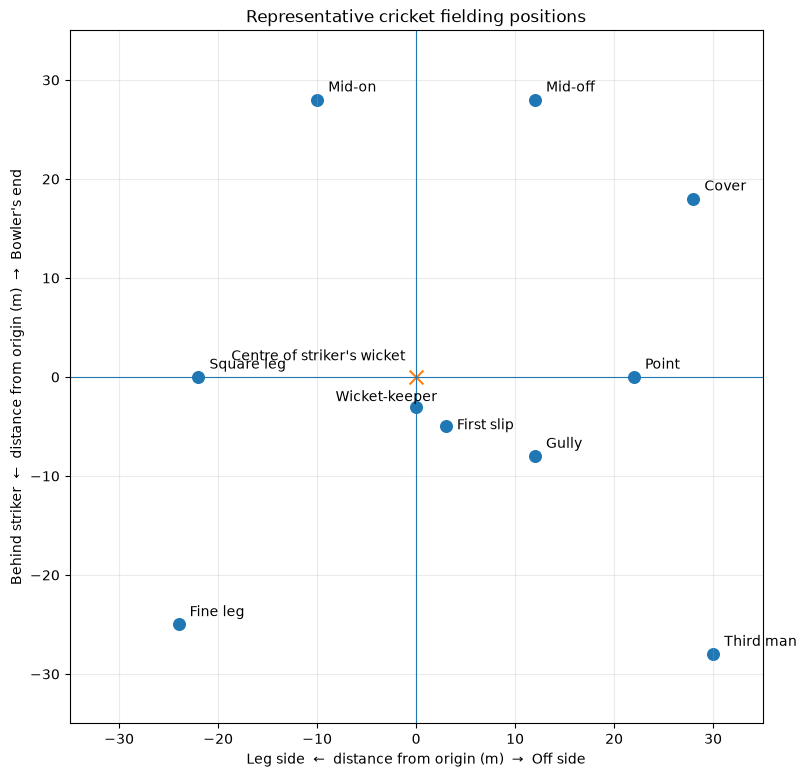

In [2]:
import matplotlib.pyplot as plt

# Create a square plotting area so that one metre has the same visual
# distance on both axes.
fig, ax = plt.subplots(figsize=(9, 9))

# Plot each representative fielding position.
ax.scatter(field["x_m"], field["y_m"], s=70)

# Custom label offsets keep the crowded positions behind the wicket readable.
# Values are measured in display points rather than metres.
label_offsets = {
    "Wicket-keeper": (-58, 4),
    "First slip": (8, -2),
    "Gully": (8, 6),
    "Point": (8, 6),
    "Cover": (8, 6),
    "Mid-off": (8, 6),
    "Mid-on": (8, 6),
    "Square leg": (8, 6),
    "Fine leg": (8, 6),
    "Third man": (8, 6),
}

# Label each fielding position.
for _, row in field.iterrows():
    dx, dy = label_offsets[row["position"]]

    ax.annotate(
        row["position"],
        (row["x_m"], row["y_m"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
    )

# Mark the centre of the striker's wicket, which is our coordinate origin.
ax.scatter(0, 0, marker="x", s=100)

# Put the origin label above and to the left so that it does not overlap
# with the wicket-keeper or first slip.
ax.annotate(
    "Centre of striker's wicket",
    (0, 0),
    xytext=(-8, 12),
    textcoords="offset points",
    ha="right",
    fontsize=10,
)

# Draw the coordinate axes through the origin.
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

# Keep the same scale in both directions so the geometry is meaningful.
ax.set_aspect("equal", adjustable="box")

# Give the positions some space around the edges.
ax.set_xlim(-35, 35)
ax.set_ylim(-35, 35)

# Axis labels describe our analytical coordinate convention.
ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Representative cricket fielding positions")
ax.grid(alpha=0.25)

plt.show()

## Measuring distance from the striker's wicket

Once fielding positions have coordinates, we can begin to measure their spatial relationships.

The simplest measurement is the distance of each fielder from our origin: the centre of the striker's wicket.

For a position with coordinates:

$$
(x,y)
$$

the straight-line distance from the origin is given by the Euclidean distance:

$$
d = \sqrt{x^2 + y^2}
$$

Because our coordinates are measured in metres, the resulting distance is also measured in metres.

This gives us a useful first distinction between positions that are relatively **close to the wicket** and positions that are positioned much deeper in the field.

For example, we would expect the wicket-keeper and first slip to be much closer to the origin than positions such as third man, fine leg or cover.

The calculation itself is simple, but it demonstrates an important change in representation: once traditional fielding positions have been converted into coordinates, questions that were previously descriptive can be answered numerically.

In [3]:
import numpy as np

# Calculate straight-line distance from the origin for every fielding position.
#
# Because x_m and y_m are measured in metres, the resulting distance is also
# measured in metres.
field["distance_m"] = np.sqrt(
    field["x_m"] ** 2 + field["y_m"] ** 2
)

# Round only for display so that the underlying values remain available
# at full precision for later calculations.
field[["position", "x_m", "y_m", "distance_m"]].round(
    {"distance_m": 1}
).sort_values("distance_m")

,position,x_m,y_m,distance_m
0,Wicket-keeper,0,-3,3.0
1,First slip,3,-5,5.8
2,Gully,12,-8,14.4
3,Point,22,0,22.0
7,Square leg,-22,0,22.0
6,Mid-on,-10,28,29.7
5,Mid-off,12,28,30.5
4,Cover,28,18,33.3
8,Fine leg,-24,-25,34.7
9,Third man,30,-28,41.0


## Adding the bowler's end as a fixed landmark

Our fielding positions are defined relative to the centre of the striker's wicket.

That also gives us a second fixed landmark: the centre of the wicket at the bowler's end.

The Laws specify the pitch length as:

$$
20.12\text{ m}
$$

so in our coordinate system the centre of the bowler's wicket is:

$$
(0,\ 20.12)
$$

This is different from assigning a coordinate to the bowler.

The **wicket** is a fixed physical landmark, whereas the bowler's exact position changes during the run-up and delivery.

For now, we will therefore add the bowler's-end wicket to the diagram as a reference point without pretending that the bowler occupies one fixed location.

This also gives the plot a useful sense of scale: the fielding positions can now be viewed relative to the actual length of a cricket pitch.

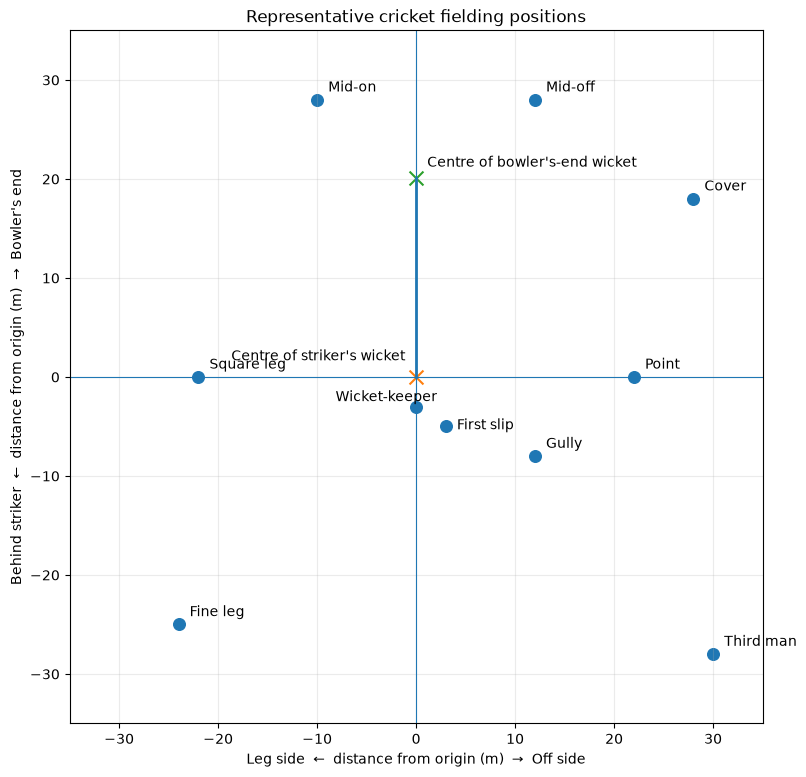

In [4]:
import matplotlib.pyplot as plt

# Create a square plotting area so that one metre has the same visual
# distance on both axes.
fig, ax = plt.subplots(figsize=(9, 9))

# Plot each representative fielding position.
ax.scatter(field["x_m"], field["y_m"], s=70)

# Custom label offsets keep crowded positions readable.
label_offsets = {
    "Wicket-keeper": (-58, 4),
    "First slip": (8, -2),
    "Gully": (8, 6),
    "Point": (8, 6),
    "Cover": (8, 6),
    "Mid-off": (8, 6),
    "Mid-on": (8, 6),
    "Square leg": (8, 6),
    "Fine leg": (8, 6),
    "Third man": (8, 6),
}

# Label each fielding position.
for _, row in field.iterrows():
    dx, dy = label_offsets[row["position"]]

    ax.annotate(
        row["position"],
        (row["x_m"], row["y_m"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
    )

# Mark the centre of the striker's wicket: our coordinate origin.
ax.scatter(0, 0, marker="x", s=100)
ax.annotate(
    "Centre of striker's wicket",
    (0, 0),
    xytext=(-8, 12),
    textcoords="offset points",
    ha="right",
    fontsize=10,
)

# Mark the centre of the bowler's-end wicket using the official
# pitch length of 20.12 metres.
bowler_wicket_y = 20.12

ax.scatter(0, bowler_wicket_y, marker="x", s=100)
ax.annotate(
    "Centre of bowler's-end wicket",
    (0, bowler_wicket_y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
)

# Draw a line between the two wickets to show the direction and scale
# of the pitch without yet attempting to draw the full pitch geometry.
ax.plot(
    [0, 0],
    [0, bowler_wicket_y],
    linewidth=2,
)

# Draw the coordinate axes through the striker's wicket.
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

# Keep the same scale in both directions so the geometry is meaningful.
ax.set_aspect("equal", adjustable="box")

ax.set_xlim(-35, 35)
ax.set_ylim(-35, 35)

ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Representative cricket fielding positions")
ax.grid(alpha=0.25)

plt.show()

## Measuring angle around the striker's wicket

Distance tells us how far a fielder is from the striker's wicket, but it does not tell us **where around the striker** that fielder is positioned.

For that we need an angle.

There is no universal cricket coordinate standard for this, so we will define an explicit analytical convention that matches the orientation of our field diagram.

We will measure angle from the direction of the **bowler's end**:

- $0^\circ$ = straight towards the bowler's end;
- $+90^\circ$ = square on the off side;
- $-90^\circ$ = square on the leg side;
- angles approaching $+180^\circ$ or $-180^\circ$ = directly behind the striker's wicket.

So, viewed from above:

$$
\begin{array}{c}
0^\circ \\
\text{bowler's end} \\
\uparrow \\
\\
-90^\circ \quad \text{leg side}
\qquad (0,0) \qquad
\text{off side} \quad +90^\circ \\
\\
\downarrow \\
\text{behind the striker's wicket} \\
\pm180^\circ
\end{array}
$$

For coordinates $(x,y)$, we can calculate this angle using:

$$
\theta = \operatorname{atan2}(x,y)
$$

and convert the result from radians to degrees.

Together, distance and angle give us a simple polar description of each fielding position:

$$
(x,y)
\rightarrow
(d,\theta)
$$

This means that a named cricket position can now be described not only by where it appears on a diagram, but also by **how far it is from the wicket and in what direction it lies**.

In [5]:
# Calculate the angle of each fielding position around the striker's wicket.
#
# Our convention is:
#    0°   -> towards the bowler's end
#   +90°  -> square on the off side
#   -90°  -> square on the leg side
#   ±180° -> directly behind the striker's wicket
#
# np.arctan2 normally takes (y, x). We deliberately pass (x, y)
# because we want the positive y-axis — towards the bowler's end —
# to act as our 0° direction.

field["angle_deg"] = np.degrees(
    np.arctan2(field["x_m"], field["y_m"])
)

# Show the spatial description of each position using both distance
# and angle from the centre of the striker's wicket.
field[
    ["position", "distance_m", "angle_deg"]
].round(
    {
        "distance_m": 1,
        "angle_deg": 1,
    }
).sort_values("angle_deg")

,position,distance_m,angle_deg
8,Fine leg,34.7,-136.2
7,Square leg,22.0,-90.0
6,Mid-on,29.7,-19.7
5,Mid-off,30.5,23.2
4,Cover,33.3,57.3
3,Point,22.0,90.0
2,Gully,14.4,123.7
9,Third man,41.0,133.0
1,First slip,5.8,149.0
0,Wicket-keeper,3.0,180.0


## Seeing distance and angle on the field

The table gives us two useful measurements for each fielding position:

- **distance** from the centre of the striker's wicket;
- **angle** around the striker's wicket.

A diagram can make those measurements easier to interpret.

We will draw a line from the origin to each fielding position. Each line therefore represents the position's distance and direction simultaneously.

Geometrically, each fielder can now be described in two equivalent ways:

$$
(x,y)
$$

or:

$$
(d,\theta)
$$

where $d$ is the distance from the striker's wicket and $\theta$ is the angle around it.

This is useful because cricket descriptions often contain both ideas implicitly. A position may be described as **square**, **fine**, **straight**, **deep** or **close**, all of which refer in some way to direction or distance.

Our coordinate model gives those spatial ideas numerical representations that we can inspect and compare.

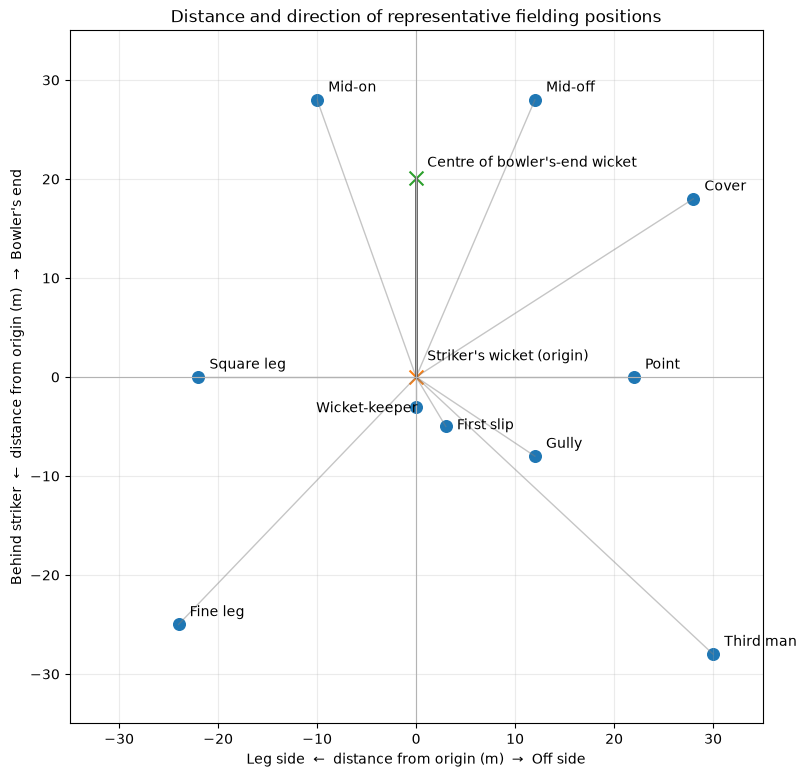

In [6]:
# Plot the field again, this time showing the radial relationship between
# the striker's wicket and every fielding position.

fig, ax = plt.subplots(figsize=(9, 9))

# Draw a neutral line from the origin to each fielder.
# Each spoke represents the distance and direction of that position.
for _, row in field.iterrows():
    ax.plot(
        [0, row["x_m"]],
        [0, row["y_m"]],
        linewidth=1,
        alpha=0.45,
        color="0.5",
    )

# Plot the fielding positions on top of the spokes.
ax.scatter(field["x_m"], field["y_m"], s=70)

# Custom label offsets keep crowded positions readable.
label_offsets = {
    "Wicket-keeper": (-72, -4),
    "First slip": (8, -2),
    "Gully": (8, 6),
    "Point": (8, 6),
    "Cover": (8, 6),
    "Mid-off": (8, 6),
    "Mid-on": (8, 6),
    "Square leg": (8, 6),
    "Fine leg": (8, 6),
    "Third man": (8, 6),
}

# Label each fielding position.
for _, row in field.iterrows():
    dx, dy = label_offsets[row["position"]]

    ax.annotate(
        row["position"],
        (row["x_m"], row["y_m"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
    )

# Mark the centre of the striker's wicket: our coordinate origin.
ax.scatter(0, 0, marker="x", s=100)

# Use a short origin label and place it above-right to avoid overlap
# with square leg and the wicket-keeper.
ax.annotate(
    "Striker's wicket (origin)",
    (0, 0),
    xytext=(8, 12),
    textcoords="offset points",
    ha="left",
    fontsize=10,
)

# Mark the centre of the bowler's-end wicket.
ax.scatter(0, bowler_wicket_y, marker="x", s=100)

ax.annotate(
    "Centre of bowler's-end wicket",
    (0, bowler_wicket_y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
)

# Show the line between the two wickets to establish the scale and
# orientation of the pitch.
ax.plot(
    [0, 0],
    [0, bowler_wicket_y],
    linewidth=2,
    color="0.35",
)

# Draw coordinate axes through the striker's wicket.
ax.axhline(0, linewidth=0.8, color="0.7")
ax.axvline(0, linewidth=0.8, color="0.7")

# Preserve real geometric proportions.
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-35, 35)
ax.set_ylim(-35, 35)

ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Distance and direction of representative fielding positions")
ax.grid(alpha=0.25)

plt.show()

## Dividing the field into broad regions

Distance and angle describe individual fielding positions, but we can also ask how fielders are distributed across larger areas of the field.

Cricket already gives us useful spatial language for this.

We can distinguish between:

- the **off side** and the **leg side**;
- positions **in front of square** and **behind square**.

Using our coordinate system, we can turn those descriptions into four broad analytical regions:

| Region | Coordinate rule |
|---|---|
| Off side, in front of square | $x > 0,\ y > 0$ |
| Off side, behind square | $x > 0,\ y < 0$ |
| Leg side, in front of square | $x < 0,\ y > 0$ |
| Leg side, behind square | $x < 0,\ y < 0$ |

Positions that lie directly on an axis require a separate decision. For example, the wicket-keeper lies on:

$$
x = 0
$$

and is therefore directly behind the striker's wicket rather than naturally belonging to either the off side or leg side.

These four regions are deliberately coarse. They do not replace traditional position names such as **cover**, **gully** or **fine leg**.

Instead, they give us another level of representation:

$$
\text{named position}
\rightarrow
(x,y)
\rightarrow
\text{field region}
$$

That will allow us to measure how a field setting distributes players across different parts of the field.

In [7]:
# Classify each fielding position into one of the broad spatial regions.
#
# The four main regions are defined by the signs of x and y:
#   x > 0, y > 0  -> off side, in front of square
#   x > 0, y < 0  -> off side, behind square
#   x < 0, y > 0  -> leg side, in front of square
#   x < 0, y < 0  -> leg side, behind square
#
# Positions on an axis are kept separate rather than forcing them into
# a region that they do not naturally belong to.

def classify_region(row):
    x = row["x_m"]
    y = row["y_m"]

    if x == 0 and y < 0:
        return "Directly behind wicket"

    if x == 0 and y > 0:
        return "Straight in front"

    if y == 0 and x > 0:
        return "Square off side"

    if y == 0 and x < 0:
        return "Square leg side"

    if x > 0 and y > 0:
        return "Off side, in front of square"

    if x > 0 and y < 0:
        return "Off side, behind square"

    if x < 0 and y > 0:
        return "Leg side, in front of square"

    if x < 0 and y < 0:
        return "Leg side, behind square"

    return "Origin"


field["region"] = field.apply(classify_region, axis=1)

field[
    ["position", "x_m", "y_m", "region"]
].sort_values("region")

,position,x_m,y_m,region
0,Wicket-keeper,0,-3,Directly behind wicket
8,Fine leg,-24,-25,"Leg side, behind square"
6,Mid-on,-10,28,"Leg side, in front of square"
1,First slip,3,-5,"Off side, behind square"
2,Gully,12,-8,"Off side, behind square"
9,Third man,30,-28,"Off side, behind square"
4,Cover,28,18,"Off side, in front of square"
5,Mid-off,12,28,"Off side, in front of square"
7,Square leg,-22,0,Square leg side
3,Point,22,0,Square off side


## How is the field distributed across regions?

Once every position has been assigned to a broad spatial region, we can summarise the structure of the field.

Instead of asking only:

> Where is each individual fielder?

we can also ask:

> How many fielders occupy each part of the field?

This gives us a simple way to describe the balance of a field setting.

For example, we can compare:

- off side versus leg side;
- in front of square versus behind square;
- square positions versus deeper angular regions;
- how concentrated the field is in particular areas.

At this stage, the counts describe only our illustrative set of positions. They should not be interpreted as an optimal or typical cricket field.

The value of the exercise is methodological: once a field has been represented spatially, its overall structure can be summarised numerically as well as visually.

In [8]:
# Count how many fielding positions fall into each broad spatial region.
region_counts = (
    field["region"]
    .value_counts()
    .rename_axis("region")
    .reset_index(name="fielders")
)

# Sort the regions by number of fielders so that the overall concentration
# of the field is easy to compare.
region_counts = region_counts.sort_values(
    ["fielders", "region"],
    ascending=[True, True],
)

region_counts

,region,fielders
2,Directly behind wicket,1
6,"Leg side, behind square",1
4,"Leg side, in front of square",1
5,Square leg side,1
3,Square off side,1
1,"Off side, in front of square",2
0,"Off side, behind square",3


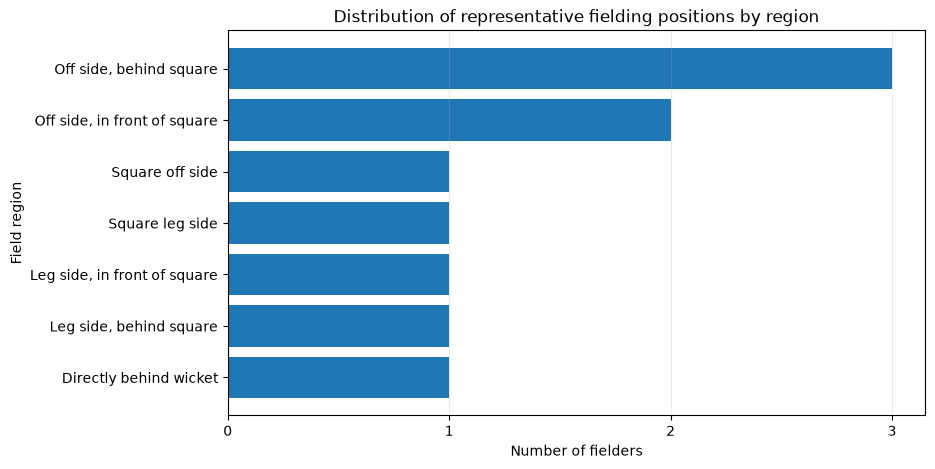

In [9]:
# A horizontal bar chart works well here because several region names
# are too long to read comfortably on a vertical axis.

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    region_counts["region"],
    region_counts["fielders"],
)

ax.set_xlabel("Number of fielders")
ax.set_ylabel("Field region")
ax.set_title("Distribution of representative fielding positions by region")

# The counts are small whole numbers, so show integer ticks only.
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax.grid(axis="x", alpha=0.25)

plt.show()

## Off side versus leg side

The regional classification can also be collapsed into one of the most fundamental spatial divisions in cricket: the **off side** and the **leg side**.

Using the sign of the $x$ coordinate:

- $x > 0$ identifies a position on the off side;
- $x < 0$ identifies a position on the leg side;
- $x = 0$ identifies a position directly in line with the wickets.

This gives us a much simpler summary of the field.

Our illustrative positions already appear visually concentrated on the off side. Counting them allows us to express that imbalance directly rather than relying only on inspection of the diagram.

This kind of summary will become more useful when we compare complete field settings later in the study. Two fields may contain similar named positions while distributing their fielders very differently between the off side and leg side.

In [10]:
# Classify each position by its broad side of the field.
#
# In our coordinate system:
#   x > 0  -> off side
#   x < 0  -> leg side
#   x = 0  -> directly in line with the wickets

def classify_side(x):
    if x > 0:
        return "Off side"
    if x < 0:
        return "Leg side"
    return "Straight"


field["side"] = field["x_m"].apply(classify_side)

# Count how many representative positions fall on each side.
side_counts = (
    field["side"]
    .value_counts()
    .reindex(["Off side", "Leg side", "Straight"], fill_value=0)
    .rename_axis("side")
    .reset_index(name="fielders")
)

side_counts

,side,fielders
0,Off side,6
1,Leg side,3
2,Straight,1


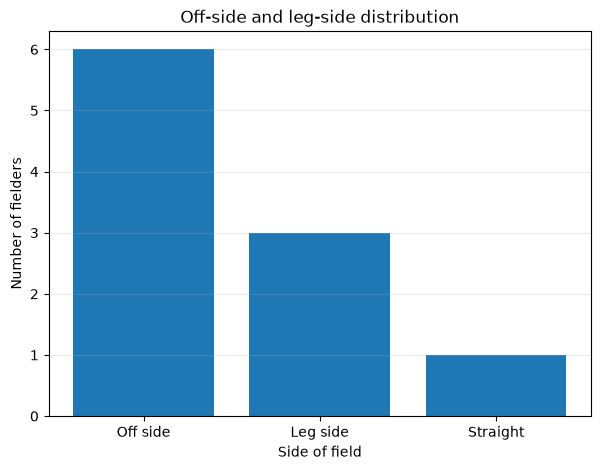

In [11]:
# Visualise the broad off-side / leg-side balance of the field.

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    side_counts["side"],
    side_counts["fielders"],
)

ax.set_xlabel("Side of field")
ax.set_ylabel("Number of fielders")
ax.set_title("Off-side and leg-side distribution")

# The counts are small whole numbers, so use integer tick marks.
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax.grid(axis="y", alpha=0.25)

plt.show()

## Distance bands around the striker's wicket

The field can also be described in terms of how far fielders are positioned from the striker's wicket.

Rather than looking only at the exact distance of each position, we can draw concentric circles around the origin. These provide visual reference bands for comparing how close or deep different positions are.

For this study, we will use circles at:

$$
10,\ 20,\ 30,\ 40\text{ m}
$$

These distances are **analytical reference bands**, not official cricket fielding categories.

They allow us to see immediately that positions such as the wicket-keeper, first slip and gully are concentrated much closer to the wicket, while positions such as cover, fine leg and third man lie considerably farther away.

The same idea could later be used to compare complete field settings. An attacking field might concentrate more fielders closer to the striker, while a more defensive field could place more fielders deeper.

For now, the aim is simply to make **radial distance** visible on the field itself.

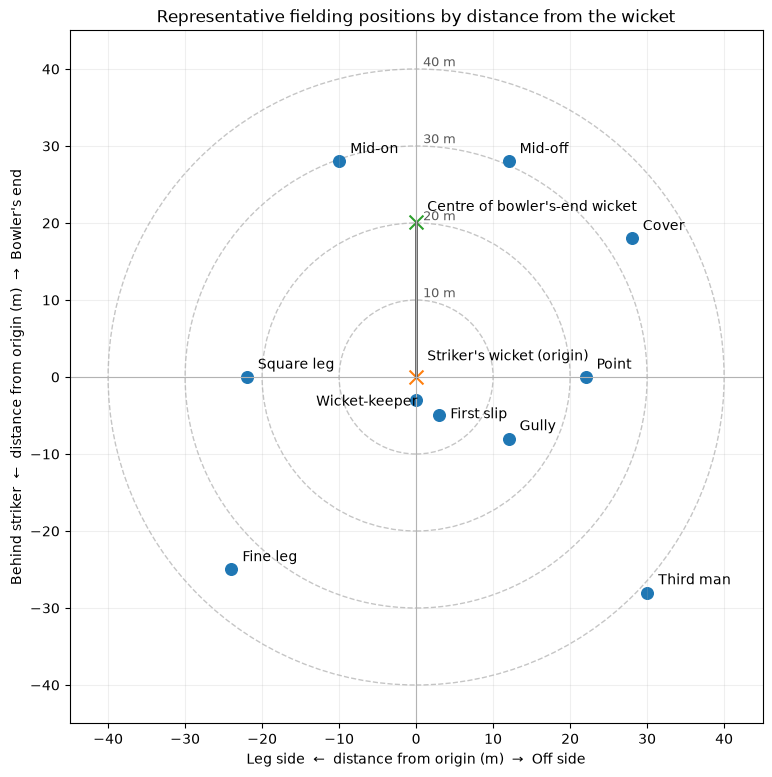

In [12]:
from matplotlib.patches import Circle

# Plot the representative fielding positions with concentric distance bands
# centred on the striker's wicket.

fig, ax = plt.subplots(figsize=(9, 9))

# Draw analytical distance bands at 10 m intervals.
# These are reference circles for the study, not official cricket zones.
distance_bands = [10, 20, 30, 40]

for radius in distance_bands:
    circle = Circle(
        (0, 0),
        radius,
        fill=False,
        linewidth=1,
        linestyle="--",
        alpha=0.45,
        color="0.5",
    )
    ax.add_patch(circle)

    # Label each band near the top of the circle.
    ax.annotate(
        f"{radius} m",
        (0, radius),
        xytext=(5, 2),
        textcoords="offset points",
        fontsize=9,
        color="0.35",
    )

# Plot the fielding positions.
ax.scatter(
    field["x_m"],
    field["y_m"],
    s=70,
)

# Label each position using the offsets already established earlier.
for _, row in field.iterrows():
    dx, dy = label_offsets[row["position"]]

    ax.annotate(
        row["position"],
        (row["x_m"], row["y_m"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
    )

# Mark the striker's wicket, which is the centre of all distance measurements.
ax.scatter(0, 0, marker="x", s=100)

ax.annotate(
    "Striker's wicket (origin)",
    (0, 0),
    xytext=(8, 12),
    textcoords="offset points",
    ha="left",
    fontsize=10,
)

# Mark the bowler's-end wicket using the 20.12 m pitch length.
ax.scatter(
    0,
    bowler_wicket_y,
    marker="x",
    s=100,
)

ax.annotate(
    "Centre of bowler's-end wicket",
    (0, bowler_wicket_y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
)

# Show the line of the pitch between the two wickets.
ax.plot(
    [0, 0],
    [0, bowler_wicket_y],
    linewidth=2,
    color="0.35",
)

# Draw the main coordinate axes.
ax.axhline(0, linewidth=0.8, color="0.7")
ax.axvline(0, linewidth=0.8, color="0.7")

# Extend the limits far enough to show the 40 m reference circle.
ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)

# Equal scaling is essential: otherwise the circles would appear as ellipses
# and the spatial distances would be misleading.
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Representative fielding positions by distance from the wicket")
ax.grid(alpha=0.2)

plt.show()

## Measuring the spacing between fielders

So far, every distance has been measured from the centre of the striker's wicket.

A field setting also has another important spatial property: **how the fielders are positioned relative to one another**.

For two fielders at:

$$
(x_1,y_1)
$$

and:

$$
(x_2,y_2)
$$

their straight-line separation is:

$$
d_{12}
=
\sqrt{
(x_2-x_1)^2
+
(y_2-y_1)^2
}
$$

This allows us to ask questions such as:

- which fielders are positioned closest together;
- where the field contains relatively tight groups;
- where large gaps exist between neighbouring positions;
- whether a field is spatially concentrated or widely dispersed.

This is different from simply knowing that two fielders are both close to the striker's wicket. They may still be positioned on opposite sides of the field.

We will begin by calculating the distance between **every pair of fielding positions**.

That pairwise distance information will then give us a basis for examining spacing and, later, simple forms of spatial clustering.

In [13]:
from itertools import combinations

# Calculate the straight-line distance between every pair of represented
# fielding positions.
#
# With 10 fielders in the current spatial model, there are:
#
#   10 choose 2 = 45
#
# unique pairs.

pairwise_distances = []

for (_, fielder_a), (_, fielder_b) in combinations(field.iterrows(), 2):
    dx = fielder_b["x_m"] - fielder_a["x_m"]
    dy = fielder_b["y_m"] - fielder_a["y_m"]

    distance = np.sqrt(dx**2 + dy**2)

    pairwise_distances.append(
        {
            "fielder_1": fielder_a["position"],
            "fielder_2": fielder_b["position"],
            "distance_m": distance,
        }
    )

pairwise = pd.DataFrame(pairwise_distances)

# Show the closest pairs first.
pairwise.sort_values("distance_m").head(10).round(
    {"distance_m": 1}
)

,fielder_1,fielder_2,distance_m
0,Wicket-keeper,First slip,3.6
9,First slip,Gully,9.5
17,Gully,Point,12.8
1,Wicket-keeper,Gully,13.0
30,Cover,Mid-off,18.9
24,Point,Cover,19.0
10,First slip,Point,19.6
35,Mid-off,Mid-on,22.0
6,Wicket-keeper,Square leg,22.2
2,Wicket-keeper,Point,22.2


## Local spacing and simple spatial clusters

The pairwise distances show that some fielding positions are much more tightly grouped than others.

In our illustrative field, the smallest separations occur among positions such as:

- wicket-keeper;
- first slip;
- gully.

These positions form a relatively compact group behind the striker's wicket on the off side.

Other parts of the field are much more widely spaced. For example, deeper positions such as fine leg and third man occupy large areas away from the close-catching group.

This suggests another way of describing a field setting:

> not only by where individual fielders stand, but by how tightly or loosely groups of fielders are arranged.

We do not yet need a complicated clustering algorithm.

A simple first measure is the distance from each fielder to their **nearest other fielder**.

For each position, we can calculate:

$$
d_{\text{nearest}}
=
\min_{j \ne i} d_{ij}
$$

A small nearest-neighbour distance indicates that a fielder is positioned close to another member of the fielding side, while a larger value suggests a more isolated position.

This gives us a simple numerical measure of local spacing that we can later compare between different field settings.

In [14]:
# Find the nearest other represented fielder for each position.
#
# This uses the pairwise distances calculated above. For each fielder,
# we collect every pair that contains that fielder, then keep the
# smallest distance.

nearest_neighbours = []

for position in field["position"]:
    # Find every pairwise distance involving this fielder.
    involving_position = pairwise[
        (pairwise["fielder_1"] == position)
        | (pairwise["fielder_2"] == position)
    ].copy()

    # The nearest neighbour is simply the pair with the smallest distance.
    nearest_row = involving_position.loc[
        involving_position["distance_m"].idxmin()
    ]

    # Work out which name in the pair is the other fielder.
    if nearest_row["fielder_1"] == position:
        nearest_position = nearest_row["fielder_2"]
    else:
        nearest_position = nearest_row["fielder_1"]

    nearest_neighbours.append(
        {
            "position": position,
            "nearest_fielder": nearest_position,
            "nearest_distance_m": nearest_row["distance_m"],
        }
    )

nearest = pd.DataFrame(nearest_neighbours)

# Show the most tightly grouped positions first.
nearest.sort_values("nearest_distance_m").round(
    {"nearest_distance_m": 1}
)

,position,nearest_fielder,nearest_distance_m
0,Wicket-keeper,First slip,3.6
1,First slip,Wicket-keeper,3.6
2,Gully,First slip,9.5
3,Point,Gully,12.8
4,Cover,Mid-off,18.9
5,Mid-off,Cover,18.9
6,Mid-on,Mid-off,22.0
7,Square leg,Wicket-keeper,22.2
8,Fine leg,Square leg,25.1
9,Third man,Gully,26.9


## Visualising nearest-neighbour relationships

The nearest-neighbour table identifies the closest other fielder to each position, but the structure is easier to understand on the field itself.

We can draw a line from each fielder to their nearest neighbour.

This creates a simple spatial network:

$$
\text{fielder}
\rightarrow
\text{nearest fielder}
$$

Closely grouped positions should produce short connections, while more isolated positions will require longer ones.

In our illustrative field, we expect the wicket-keeper, first slip and gully to form a visibly compact group behind the striker's wicket. Positions farther from that group should have much longer nearest-neighbour connections.

This does not yet constitute a formal clustering model. It is simply another way of making local spacing visible.

Later, when we compare complete field settings, the same measurement can help show whether one field is more tightly concentrated or more widely dispersed than another.

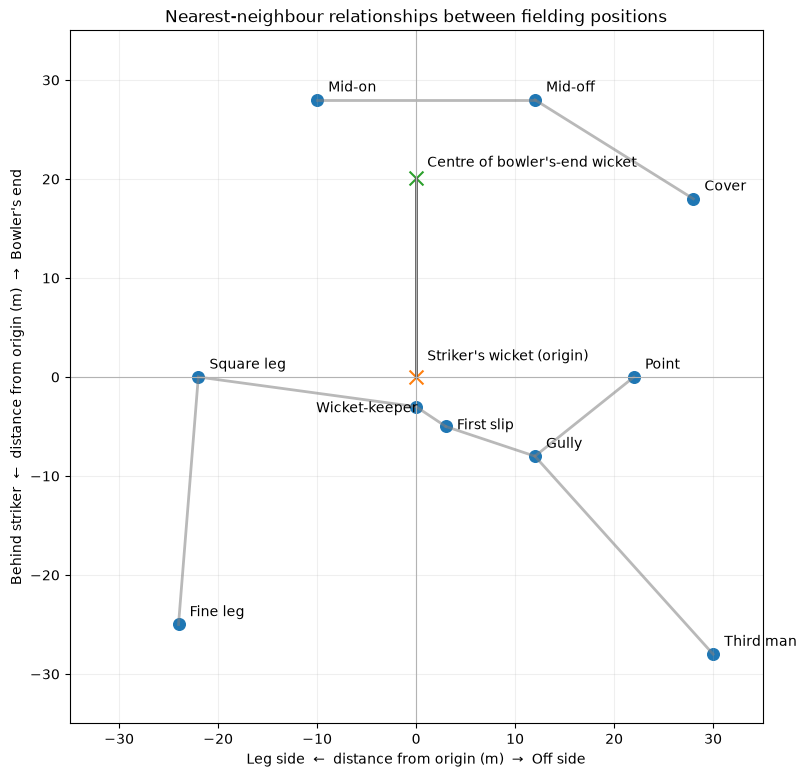

In [15]:
# Visualise the nearest-neighbour relationship for every represented fielder.

fig, ax = plt.subplots(figsize=(9, 9))

# Look up coordinates by position name so that the nearest-neighbour table
# can be converted back into spatial lines on the field.
coordinates = field.set_index("position")[["x_m", "y_m"]]

# Draw one neutral connection from each fielder to their nearest neighbour.
#
# Some relationships are mutual, such as wicket-keeper <-> first slip.
# Drawing both produces the same line twice, so keep track of pairs that
# have already been plotted.
drawn_pairs = set()

for _, row in nearest.iterrows():
    position = row["position"]
    neighbour = row["nearest_fielder"]

    pair = frozenset([position, neighbour])

    if pair in drawn_pairs:
        continue

    drawn_pairs.add(pair)

    x1, y1 = coordinates.loc[position]
    x2, y2 = coordinates.loc[neighbour]

    ax.plot(
        [x1, x2],
        [y1, y2],
        linewidth=2,
        alpha=0.55,
        color="0.5",
    )

# Plot the fielding positions above the connection lines.
ax.scatter(
    field["x_m"],
    field["y_m"],
    s=70,
)

# Label each fielding position.
for _, row in field.iterrows():
    dx, dy = label_offsets[row["position"]]

    ax.annotate(
        row["position"],
        (row["x_m"], row["y_m"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
    )

# Mark the striker's wicket, which remains the origin of the field model.
ax.scatter(0, 0, marker="x", s=100)

ax.annotate(
    "Striker's wicket (origin)",
    (0, 0),
    xytext=(8, 12),
    textcoords="offset points",
    ha="left",
    fontsize=10,
)

# Mark the bowler's-end wicket as the second fixed landmark.
ax.scatter(
    0,
    bowler_wicket_y,
    marker="x",
    s=100,
)

ax.annotate(
    "Centre of bowler's-end wicket",
    (0, bowler_wicket_y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
)

# Show the pitch direction and scale.
ax.plot(
    [0, 0],
    [0, bowler_wicket_y],
    linewidth=2,
    color="0.35",
)

# Draw the main coordinate axes.
ax.axhline(0, linewidth=0.8, color="0.7")
ax.axvline(0, linewidth=0.8, color="0.7")

# Preserve the real spatial proportions.
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-35, 35)
ax.set_ylim(-35, 35)

ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Nearest-neighbour relationships between fielding positions")
ax.grid(alpha=0.2)

plt.show()

## Summarising local spacing

Nearest-neighbour distances give us one value for each fielder, so we can also summarise the overall spacing of the field.

Useful descriptive measures include:

- the **mean nearest-neighbour distance**;
- the **median nearest-neighbour distance**;
- the smallest nearest-neighbour distance;
- the largest nearest-neighbour distance.

These numbers do not tell us whether a field is good or bad, attacking or defensive.

They simply describe one aspect of its spatial structure: how far, on average, each represented fielder is from their closest teammate.

This will become more useful when two complete field settings are represented using the same coordinate system. We will then be able to compare their spacing using the same measurements rather than relying only on visual inspection.

In [16]:
# Summarise the nearest-neighbour distances across the represented fielders.
#
# These values describe local spacing only. They do not by themselves
# imply anything about whether the field is tactically good or bad.

spacing_summary = pd.DataFrame(
    {
        "measure": [
            "Mean nearest-neighbour distance",
            "Median nearest-neighbour distance",
            "Minimum nearest-neighbour distance",
            "Maximum nearest-neighbour distance",
        ],
        "distance_m": [
            nearest["nearest_distance_m"].mean(),
            nearest["nearest_distance_m"].median(),
            nearest["nearest_distance_m"].min(),
            nearest["nearest_distance_m"].max(),
        ],
    }
)

spacing_summary.round({"distance_m": 1})

,measure,distance_m
0,Mean nearest-neighbour distance,16.3
1,Median nearest-neighbour distance,18.9
2,Minimum nearest-neighbour distance,3.6
3,Maximum nearest-neighbour distance,26.9


## From named positions to complete field settings

So far, we have used a collection of representative fielding positions to develop the spatial model.

We can now use the same framework to represent a **complete fielding side**.

A complete field setting needs to account for all 11 players on the fielding side:

- the bowler;
- the wicket-keeper;
- nine other fielders.

For the bowler, we need one additional modelling convention.

The bowler is not stationary during a delivery. Their exact position when the ball reaches the striker depends on the delivery and the bowler's follow-through.

Because this study is modelling **field settings rather than player tracking**, we will represent the bowler schematically at the bowler's end:

$$
(0,\ 20.12)
$$

This is the same coordinate as the centre of the bowler's-end wicket. It should therefore be interpreted as the bowler's **field-setting reference position**, not as a claim about their exact location at the instant the ball is struck.

With a complete XI represented in the same coordinate system, we can begin comparing different field settings using the measurements developed above:

- distance from the striker's wicket;
- angular position;
- off-side and leg-side balance;
- regional distribution;
- spacing between fielders.

The aim is not yet to determine an optimal field.

It is to ask a simpler question:

> **Can two recognisably different cricket field settings be distinguished quantitatively from their spatial structure?**

## An illustrative attacking field

We will begin with a complete field setting designed to be recognisably **attacking**.

The purpose is not to claim that there is one standard attacking field. Field settings depend on the bowler, striker, conditions and match situation.

Instead, we will construct one plausible example containing a relatively strong **slip cordon** and several fielders close to the striker.

The fielding side will contain:

- bowler;
- wicket-keeper;
- first slip;
- second slip;
- third slip;
- gully;
- point;
- cover;
- mid-off;
- mid-on;
- fine leg.

This gives us all 11 members of the fielding side.

As before, the position names come from cricket, while the exact coordinates will be **representative modelling choices**.

The important feature of this setting is its spatial structure: several fielders will be concentrated behind the striker's wicket on the off side, particularly around the wicket-keeper and slips.

Once this field has been represented as coordinates, we can measure it using exactly the same tools developed earlier.

In [17]:
# Construct one illustrative attacking field setting.
#
# This is now a complete fielding side of 11 players:
#   1 bowler
#   1 wicket-keeper
#   9 other fielders
#
# The named positions are standard cricket terminology, but the precise
# coordinates are modelling choices for this study.
#
# The bowler is represented schematically at the bowler's-end wicket
# (0, 20.12). This is a field-setting reference position, not an attempt
# to track the bowler's actual position during the follow-through.

attacking_positions = [
    {"position": "Bowler",        "x_m": 0.0,   "y_m": 20.12},
    {"position": "Wicket-keeper", "x_m": 0.0,   "y_m": -3.0},
    {"position": "First slip",    "x_m": 3.0,   "y_m": -5.0},
    {"position": "Second slip",   "x_m": 5.5,   "y_m": -5.5},
    {"position": "Third slip",    "x_m": 8.0,   "y_m": -6.0},
    {"position": "Gully",         "x_m": 12.0,  "y_m": -8.0},
    {"position": "Point",         "x_m": 22.0,  "y_m": 0.0},
    {"position": "Cover",         "x_m": 28.0,  "y_m": 18.0},
    {"position": "Mid-off",       "x_m": 12.0,  "y_m": 28.0},
    {"position": "Mid-on",        "x_m": -10.0, "y_m": 28.0},
    {"position": "Fine leg",      "x_m": -24.0, "y_m": -25.0},
]

attacking_field = pd.DataFrame(attacking_positions)

attacking_field

,position,x_m,y_m
0,Bowler,0.0,20.12
1,Wicket-keeper,0.0,-3.00
2,First slip,3.0,-5.00
3,Second slip,5.5,-5.50
4,Third slip,8.0,-6.00
5,Gully,12.0,-8.00
6,Point,22.0,0.00
7,Cover,28.0,18.00
8,Mid-off,12.0,28.00
9,Mid-on,-10.0,28.00


## Plotting the complete attacking field

We can now plot the complete fielding side using the same coordinate system as before.

This time the diagram includes all 11 players, including the bowler represented schematically at the bowler's end.

The main feature to look for is the concentration of fielders behind the striker's wicket on the off side:

- wicket-keeper;
- first slip;
- second slip;
- third slip;
- gully.

That group should appear as a dense cluster compared with the more widely spaced positions elsewhere in the field.

The purpose of the plot is not to judge whether this is the best possible attacking field.

It is to create one complete field setting whose spatial structure can later be measured and compared with a different field.

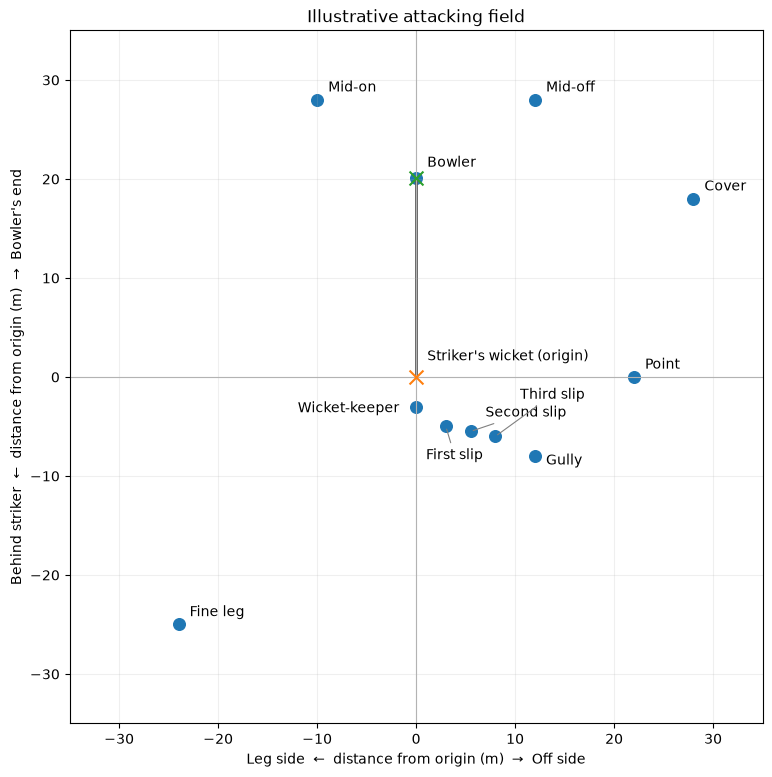

In [18]:
# Plot the complete illustrative attacking field.

fig, ax = plt.subplots(figsize=(9, 9))

# Plot all 11 members of the fielding side.
# Every player, including the bowler, uses the same marker.
ax.scatter(
    attacking_field["x_m"],
    attacking_field["y_m"],
    s=70,
)

# Most fielders can use simple label offsets.
standard_label_offsets = {
    "Wicket-keeper": (-12, -4, "right"),
    "Bowler": (8, 8, "left"),
    "Gully": (8, -6, "left"),
    "Point": (8, 6, "left"),
    "Cover": (8, 6, "left"),
    "Mid-off": (8, 6, "left"),
    "Mid-on": (8, 6, "left"),
    "Fine leg": (8, 6, "left"),
}

# Label the positions that are not part of the crowded slip cordon.
for _, row in attacking_field.iterrows():
    if row["position"] in standard_label_offsets:
        dx, dy, alignment = standard_label_offsets[row["position"]]

        ax.annotate(
            row["position"],
            (row["x_m"], row["y_m"]),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=alignment,
            fontsize=10,
        )

# The three slips are deliberately close together, so place their labels
# separately and use short leader lines back to the actual coordinates.
slip_labels = {
    "First slip": (1.0, -8.3),
    "Second slip": (7.0, -4.0),
    "Third slip": (10.5, -2.2),
}

for position, (label_x, label_y) in slip_labels.items():
    row = attacking_field[
        attacking_field["position"] == position
    ].iloc[0]

    ax.annotate(
        position,
        xy=(row["x_m"], row["y_m"]),
        xytext=(label_x, label_y),
        textcoords="data",
        fontsize=10,
        ha="left",
        arrowprops={
            "arrowstyle": "-",
            "linewidth": 0.8,
            "color": "0.5",
        },
    )

# Mark the centre of the striker's wicket: our coordinate origin.
ax.scatter(
    0,
    0,
    marker="x",
    s=100,
    zorder=4,
)

ax.annotate(
    "Striker's wicket (origin)",
    (0, 0),
    xytext=(8, 12),
    textcoords="offset points",
    ha="left",
    fontsize=10,
)

# The bowler is represented schematically at the bowler's-end wicket.
# The blue point represents the player; the x marks the fixed wicket
# landmark at the same coordinate.
ax.scatter(
    0,
    bowler_wicket_y,
    marker="x",
    s=100,
    zorder=4,
)

# Show the line between the two wickets to preserve the physical scale
# and orientation of the pitch.
ax.plot(
    [0, 0],
    [0, bowler_wicket_y],
    linewidth=2,
    color="0.35",
    zorder=1,
)

# Draw the coordinate axes through the striker's wicket.
ax.axhline(0, linewidth=0.8, color="0.7")
ax.axvline(0, linewidth=0.8, color="0.7")

# Preserve real spatial proportions.
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-35, 35)
ax.set_ylim(-35, 35)

ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Illustrative attacking field")
ax.grid(alpha=0.2)

plt.show()

## An illustrative defensive field

We can now construct a second complete field setting using the same coordinate system.

This example will be deliberately more **defensive** in its spatial structure.

Again, there is no single standard defensive field. The exact positions used in a real match would depend on the bowler, striker, format, score and match situation.

For this illustrative comparison, we will reduce the concentration of close catching positions and place more fielders deeper around the field.

The fielding side will contain:

- bowler;
- wicket-keeper;
- first slip;
- third man;
- deep point;
- deep cover;
- long-off;
- long-on;
- deep midwicket;
- deep square leg;
- fine leg.

As with the attacking field, these are representative coordinates rather than fixed definitions of where these positions must be located.

The important difference is the **spatial arrangement**.

Compared with the attacking field, we expect this field to have:

- fewer fielders concentrated close behind the striker;
- greater average distance from the striker's wicket;
- wider spacing between neighbouring fielders;
- broader coverage around the field.

We can then measure whether those visual differences also appear in the spatial statistics.

In [19]:
# Construct one illustrative defensive field setting.
#
# This is again a complete fielding side of 11 players:
#   1 bowler
#   1 wicket-keeper
#   9 other fielders
#
# Compared with the attacking field, fewer players are concentrated
# close behind the striker and more are positioned deeper around the field.
#
# The exact coordinates remain modelling choices for this study rather
# than fixed definitions of the named cricket positions.

defensive_positions = [
    {"position": "Bowler",           "x_m": 0.0,   "y_m": 20.12},
    {"position": "Wicket-keeper",    "x_m": 0.0,   "y_m": -3.0},
    {"position": "First slip",       "x_m": 3.0,   "y_m": -5.0},
    {"position": "Third man",        "x_m": 38.0,  "y_m": -32.0},
    {"position": "Deep point",       "x_m": 42.0,  "y_m": 0.0},
    {"position": "Deep cover",       "x_m": 40.0,  "y_m": 24.0},
    {"position": "Long-off",         "x_m": 18.0,  "y_m": 42.0},
    {"position": "Long-on",          "x_m": -18.0, "y_m": 42.0},
    {"position": "Deep midwicket",   "x_m": -38.0, "y_m": 26.0},
    {"position": "Deep square leg",  "x_m": -42.0, "y_m": 0.0},
    {"position": "Fine leg",         "x_m": -34.0, "y_m": -36.0},
]

defensive_field = pd.DataFrame(defensive_positions)

defensive_field

,position,x_m,y_m
0,Bowler,0.0,20.12
1,Wicket-keeper,0.0,-3.00
2,First slip,3.0,-5.00
3,Third man,38.0,-32.00
4,Deep point,42.0,0.00
5,Deep cover,40.0,24.00
6,Long-off,18.0,42.00
7,Long-on,-18.0,42.00
8,Deep midwicket,-38.0,26.00
9,Deep square leg,-42.0,0.00


## Plotting the complete defensive field

We can now plot the defensive field using exactly the same coordinate system and visual conventions as the attacking field.

Keeping the plotting system unchanged is important. If we changed the scale or orientation between the two diagrams, the comparison would become misleading.

This field should look much more spread out.

Most of the outfield positions are now around 40–50 metres from the striker's wicket, while only the wicket-keeper and first slip remain close behind the wicket.

That means we should expect to see:

- much less clustering near the striker;
- larger gaps between neighbouring fielders;
- greater radial distance overall;
- broader angular coverage around the field.

The next step is to inspect that visually before comparing the two fields numerically.

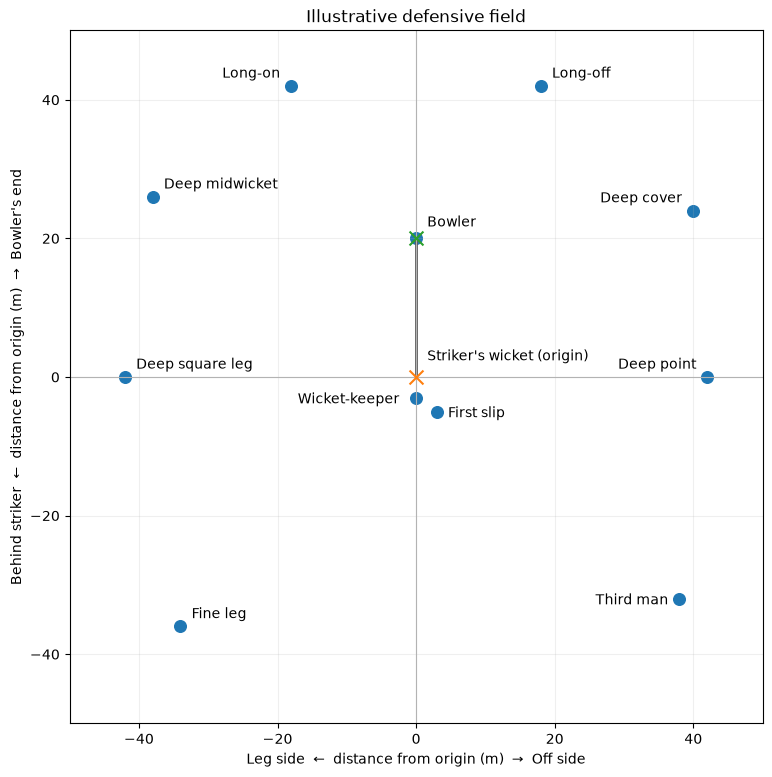

In [20]:
# Plot the complete illustrative defensive field.

fig, ax = plt.subplots(figsize=(9, 9))

# Plot all 11 members of the fielding side.
ax.scatter(
    defensive_field["x_m"],
    defensive_field["y_m"],
    s=70,
)

# Place labels so that positions near the edge of the diagram
# are labelled inward rather than being clipped by the axes.
defensive_label_offsets = {
    "Bowler": (8, 8, "left"),
    "Wicket-keeper": (-12, -4, "right"),
    "First slip": (8, -4, "left"),
    "Third man": (-8, -4, "right"),
    "Deep point": (-8, 6, "right"),
    "Deep cover": (-8, 6, "right"),
    "Long-off": (8, 6, "left"),
    "Long-on": (-8, 6, "right"),
    "Deep midwicket": (8, 6, "left"),
    "Deep square leg": (8, 6, "left"),
    "Fine leg": (8, 6, "left"),
}

# Label every player.
for _, row in defensive_field.iterrows():
    dx, dy, alignment = defensive_label_offsets[row["position"]]

    ax.annotate(
        row["position"],
        (row["x_m"], row["y_m"]),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=alignment,
        fontsize=10,
    )

# Mark the centre of the striker's wicket: our coordinate origin.
ax.scatter(
    0,
    0,
    marker="x",
    s=100,
    zorder=4,
)

ax.annotate(
    "Striker's wicket (origin)",
    (0, 0),
    xytext=(8, 12),
    textcoords="offset points",
    ha="left",
    fontsize=10,
)

# The bowler is represented schematically at the bowler's-end wicket.
# The blue point represents the player; the x marks the fixed wicket
# landmark at the same coordinate.
ax.scatter(
    0,
    bowler_wicket_y,
    marker="x",
    s=100,
    zorder=4,
)

# Show the line between the wickets to preserve the physical scale
# and orientation of the pitch.
ax.plot(
    [0, 0],
    [0, bowler_wicket_y],
    linewidth=2,
    color="0.35",
    zorder=1,
)

# Draw the coordinate axes through the striker's wicket.
ax.axhline(0, linewidth=0.8, color="0.7")
ax.axvline(0, linewidth=0.8, color="0.7")

# Keep equal scaling and use the same range in both directions.
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-50, 50)
ax.set_ylim(-50, 50)

ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Illustrative defensive field")
ax.grid(alpha=0.2)

plt.show()

## Comparing the attacking and defensive fields

We now have two complete field settings represented in exactly the same coordinate system.

That means we can compare them using the same measurements rather than relying only on visual inspection.

For each field, we will calculate:

- mean distance from the striker's wicket;
- median distance from the striker's wicket;
- mean nearest-neighbour distance;
- median nearest-neighbour distance;
- minimum nearest-neighbour distance;
- maximum nearest-neighbour distance.

These measures describe two different aspects of the field:

**Radial distance** tells us how far the fielding side is positioned from the striker's wicket overall.

**Nearest-neighbour distance** tells us how tightly or widely the fielders are spaced relative to one another.

We expect the defensive field to have a greater average distance from the striker's wicket and, because more players are spread around the outfield, greater nearest-neighbour spacing.

These expectations come from how we deliberately constructed the two illustrative fields.

The purpose of the comparison is therefore not to discover an unknown tactical truth. It is to test whether our spatial measurements successfully capture differences that are already visible in the field settings.

In [21]:
# Calculate a common set of spatial measurements for a complete field.
#
# Using one function for both settings ensures that the attacking and
# defensive fields are measured in exactly the same way.

def summarise_field_spacing(field_df, field_name):
    field_df = field_df.copy()

    # Distance of every player from the centre of the striker's wicket.
    field_df["distance_m"] = np.sqrt(
        field_df["x_m"] ** 2 + field_df["y_m"] ** 2
    )

    # Calculate every unique pairwise distance within the fielding XI.
    pair_distances = []

    for (_, player_a), (_, player_b) in combinations(field_df.iterrows(), 2):
        dx = player_b["x_m"] - player_a["x_m"]
        dy = player_b["y_m"] - player_a["y_m"]

        pair_distances.append(
            {
                "player_1": player_a["position"],
                "player_2": player_b["position"],
                "distance_m": np.sqrt(dx**2 + dy**2),
            }
        )

    pairs = pd.DataFrame(pair_distances)

    # Find the nearest teammate for each player.
    nearest_distances = []

    for position in field_df["position"]:
        involving_player = pairs[
            (pairs["player_1"] == position)
            | (pairs["player_2"] == position)
        ]

        nearest_distances.append(
            involving_player["distance_m"].min()
        )

    nearest_distances = np.array(nearest_distances)

    # Return one row containing the main spatial summary measures.
    return {
        "field": field_name,
        "mean_distance_m": field_df["distance_m"].mean(),
        "median_distance_m": field_df["distance_m"].median(),
        "mean_nearest_m": nearest_distances.mean(),
        "median_nearest_m": np.median(nearest_distances),
        "minimum_nearest_m": nearest_distances.min(),
        "maximum_nearest_m": nearest_distances.max(),
    }


field_comparison = pd.DataFrame(
    [
        summarise_field_spacing(attacking_field, "Attacking"),
        summarise_field_spacing(defensive_field, "Defensive"),
    ]
)

field_comparison.round(1)

,field,mean_distance_m,median_distance_m,mean_nearest_m,median_nearest_m,minimum_nearest_m,maximum_nearest_m
0,Attacking,19.2,20.1,10.9,12.7,2.5,32.6
1,Defensive,36.0,45.7,23.0,25.6,3.6,36.9


## What changed between the two fields?

The spatial measurements capture the difference that was visible in the diagrams.

The attacking field has a mean distance from the striker's wicket of:

$$
19.2\text{ m}
$$

compared with:

$$
36.0\text{ m}
$$

for the defensive field.

The difference is even clearer in the median distance:

$$
20.1\text{ m}
\quad \text{versus} \quad
45.7\text{ m}
$$

The defensive field therefore places much more of the fielding side deeper around the field.

The nearest-neighbour measurements show a similar change in spacing.

Mean nearest-neighbour distance increases from:

$$
10.9\text{ m}
$$

to:

$$
23.0\text{ m}
$$

while the median increases from:

$$
12.7\text{ m}
$$

to:

$$
25.6\text{ m}
$$

The minimum nearest-neighbour distance remains small in both fields. This is important: a defensive field does not require every player to be widely separated. The wicket-keeper and slip can remain close together while the rest of the field is distributed much more widely.

These measurements do not tell us that one field is strategically better than the other.

They show that two field settings which we deliberately constructed to have different spatial structures can be distinguished quantitatively using the same coordinate representation.

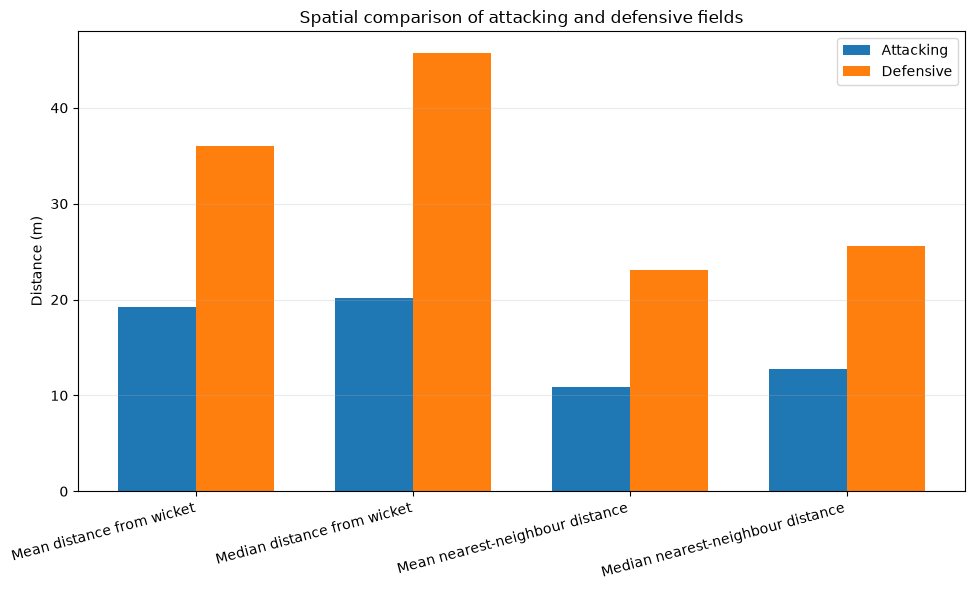

In [22]:
# Compare the main spatial measurements of the attacking and defensive fields.
#
# We use the mean and median radial distances together with the mean and
# median nearest-neighbour distances. All four measures are in metres, so
# they can be shown on the same axis without mixing units.

comparison_plot = field_comparison[
    [
        "field",
        "mean_distance_m",
        "median_distance_m",
        "mean_nearest_m",
        "median_nearest_m",
    ]
].copy()

# Reshape the table into long form so each measurement becomes a category.
comparison_long = comparison_plot.melt(
    id_vars="field",
    var_name="measure",
    value_name="distance_m",
)

# Use readable labels on the chart rather than dataframe column names.
measure_labels = {
    "mean_distance_m": "Mean distance from wicket",
    "median_distance_m": "Median distance from wicket",
    "mean_nearest_m": "Mean nearest-neighbour distance",
    "median_nearest_m": "Median nearest-neighbour distance",
}

comparison_long["measure"] = comparison_long["measure"].map(measure_labels)

# Place the attacking and defensive values side by side for each measure.
measures = comparison_long["measure"].unique()
x = np.arange(len(measures))
bar_width = 0.36

attacking_values = comparison_long[
    comparison_long["field"] == "Attacking"
]["distance_m"].to_numpy()

defensive_values = comparison_long[
    comparison_long["field"] == "Defensive"
]["distance_m"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - bar_width / 2,
    attacking_values,
    bar_width,
    label="Attacking",
)

ax.bar(
    x + bar_width / 2,
    defensive_values,
    bar_width,
    label="Defensive",
)

ax.set_xticks(x)
ax.set_xticklabels(measures, rotation=15, ha="right")

ax.set_ylabel("Distance (m)")
ax.set_title("Spatial comparison of attacking and defensive fields")
ax.legend()

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Comparing angular coverage

Distance and spacing tell us how far the fielders are from the striker and from one another.

We can also compare **how they are distributed around the striker's wicket**.

Earlier, we defined angle so that:

- $0^\circ$ points towards the bowler's end;
- $+90^\circ$ points square on the off side;
- $-90^\circ$ points square on the leg side;
- $\pm180^\circ$ points directly behind the striker's wicket.

That gives every player an angular position around the origin.

For a complete field, we can therefore ask:

- which directions contain several fielders;
- which directions are relatively empty;
- whether the field is concentrated within particular sectors;
- whether players are distributed more broadly around the striker.

This is especially relevant to our attacking and defensive examples.

The attacking field contains several players in a narrow area behind the striker on the off side, so we expect a strong angular concentration around the slip cordon.

The defensive field places more players around the perimeter of the field, so we expect its angular positions to be more widely distributed.

We will first calculate the angle of every player in both complete field settings, using the same convention as before.

In [23]:
# Calculate player angles for both complete field settings using the same
# convention introduced earlier:
#
#    0°   -> towards the bowler's end
#   +90°  -> square on the off side
#   -90°  -> square on the leg side
#   ±180° -> directly behind the striker's wicket

def add_field_angles(field_df, field_name):
    result = field_df.copy()

    result["angle_deg"] = np.degrees(
        np.arctan2(
            result["x_m"],
            result["y_m"],
        )
    )

    result["field"] = field_name

    return result


attacking_angles = add_field_angles(
    attacking_field,
    "Attacking",
)

defensive_angles = add_field_angles(
    defensive_field,
    "Defensive",
)

field_angles = pd.concat(
    [
        attacking_angles,
        defensive_angles,
    ],
    ignore_index=True,
)

field_angles[
    [
        "field",
        "position",
        "x_m",
        "y_m",
        "angle_deg",
    ]
].round(
    {
        "angle_deg": 1,
    }
)

,field,position,x_m,y_m,angle_deg
0,Attacking,Bowler,0.0,20.12,0.0
1,Attacking,Wicket-keeper,0.0,-3.00,180.0
2,Attacking,First slip,3.0,-5.00,149.0
3,Attacking,Second slip,5.5,-5.50,135.0
4,Attacking,Third slip,8.0,-6.00,126.9
5,Attacking,Gully,12.0,-8.00,123.7
6,Attacking,Point,22.0,0.00,90.0
7,Attacking,Cover,28.0,18.00,57.3
8,Attacking,Mid-off,12.0,28.00,23.2
9,Attacking,Mid-on,-10.0,28.00,-19.7


## Viewing the field in polar coordinates

Our original field diagrams used Cartesian coordinates:

$$
(x,y)
$$

but the same positions can also be viewed using:

$$
(d,\theta)
$$

where:

- $d$ is distance from the striker's wicket;
- $\theta$ is direction around the striker.

A **polar plot** is particularly well suited to this representation.

The angle around the circle shows the direction of each player, while the distance from the centre shows how far that player is from the striker's wicket.

This means the complete spatial structure of a field can be shown in a single diagram.

For the attacking field, we expect the slip cordon to appear as several points packed into a narrow angular sector behind the striker on the off side.

For the defensive field, we expect the players to occupy a much broader range of angles and, in general, to sit farther from the centre.

We will plot the two fields separately using the same radial scale so that their spatial structures can be compared directly.

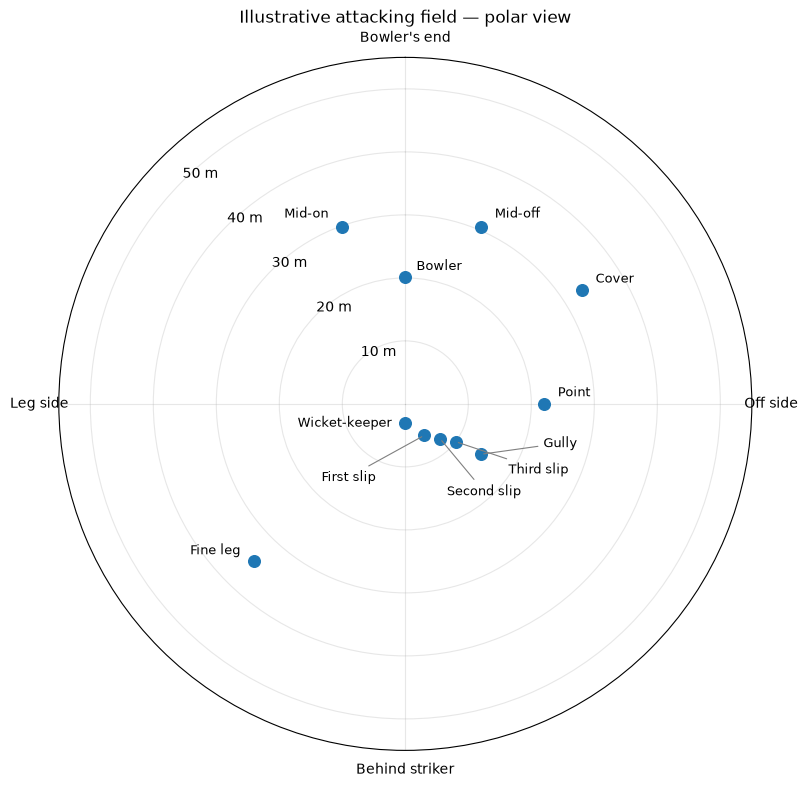

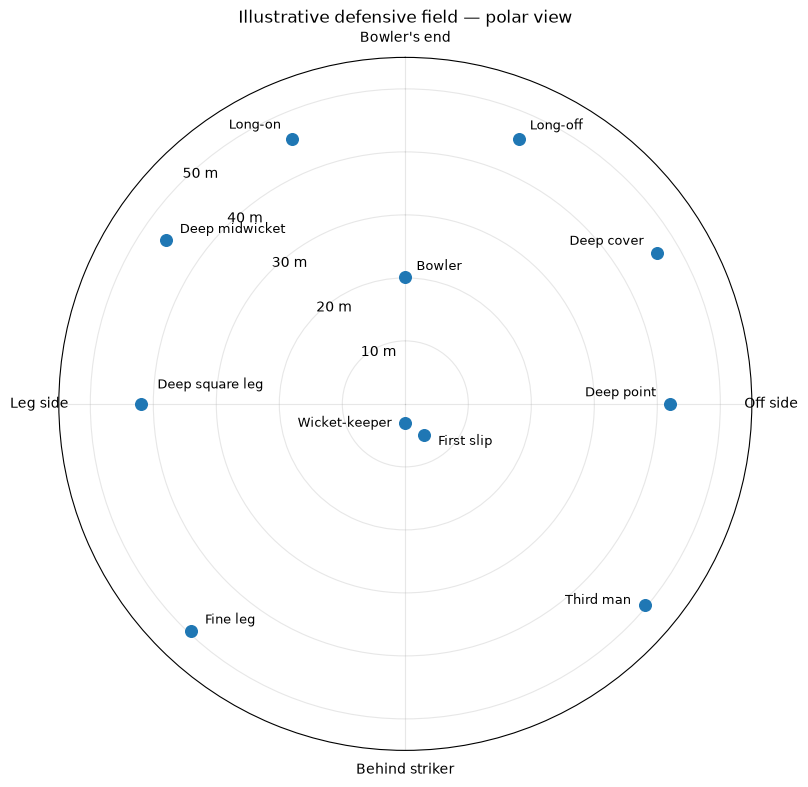

In [24]:
# Plot complete field settings in polar coordinates.
#
# Angle represents direction around the striker's wicket.
# Radius represents distance from the striker's wicket in metres.
#
# Both fields use the same 55 m radial limit so their apparent spread
# can be compared directly.
#
# The outer circle is only the plotting limit. It is not a cricket boundary.

def plot_polar_field(field_df, title, label_settings):
    plot_field = field_df.copy()

    # Convert Cartesian coordinates to radial distance and angle.
    plot_field["distance_m"] = np.sqrt(
        plot_field["x_m"] ** 2 + plot_field["y_m"] ** 2
    )

    plot_field["angle_rad"] = np.arctan2(
        plot_field["x_m"],
        plot_field["y_m"],
    )

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection="polar")

    # Match the orientation used throughout the notebook.
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # Plot all 11 players.
    ax.scatter(
        plot_field["angle_rad"],
        plot_field["distance_m"],
        s=70,
        zorder=3,
    )

    # Label every player.
    for _, row in plot_field.iterrows():
        position = row["position"]
        settings = label_settings[position]

        ax.annotate(
            position,
            xy=(
                row["angle_rad"],
                row["distance_m"],
            ),
            xytext=settings["offset"],
            textcoords="offset points",
            ha=settings.get("ha", "left"),
            va=settings.get("va", "center"),
            fontsize=9,
            arrowprops=(
                {
                    "arrowstyle": "-",
                    "linewidth": 0.8,
                    "color": "0.5",
                }
                if settings.get("leader", False)
                else None
            ),
        )

    # Use the same radial scale for both fields.
    ax.set_ylim(0, 55)
    ax.set_yticks([10, 20, 30, 40, 50])
    ax.set_yticklabels(
        ["10 m", "20 m", "30 m", "40 m", "50 m"]
    )

    # Move the radial tick labels away from mid-off.
    ax.set_rlabel_position(315)

    # Replace degree labels with cricket-oriented directions.
    ax.set_thetagrids(
        [0, 90, 180, 270],
        labels=[
            "Bowler's end",
            "Off side",
            "Behind striker",
            "Leg side",
        ],
    )

    ax.set_title(
        title,
        pad=25,
    )

    ax.grid(alpha=0.3)

    plt.show()


# The attacking slip cordon needs deliberately separated labels.
attacking_polar_labels = {
    "Bowler": {
        "offset": (8, 8),
    },
    "Wicket-keeper": {
        "offset": (-10, 0),
        "ha": "right",
    },
    "First slip": {
        "offset": (-35, -30),
        "ha": "right",
        "leader": True,
    },
    "Second slip": {
        "offset": (5, -38),
        "leader": True,
    },
    "Third slip": {
        "offset": (38, -20),
        "leader": True,
    },
    "Gully": {
        "offset": (45, 8),
        "leader": True,
    },
    "Point": {
        "offset": (10, 8),
    },
    "Cover": {
        "offset": (10, 8),
    },
    "Mid-off": {
        "offset": (10, 10),
    },
    "Mid-on": {
        "offset": (-10, 10),
        "ha": "right",
    },
    "Fine leg": {
        "offset": (-10, 8),
        "ha": "right",
    },
}


# The defensive field mainly needs its outer labels kept inside the rim.
defensive_polar_labels = {
    "Bowler": {
        "offset": (8, 8),
    },
    "Wicket-keeper": {
        "offset": (-10, 0),
        "ha": "right",
    },
    "First slip": {
        "offset": (10, -4),
    },
    "Third man": {
        "offset": (-10, 4),
        "ha": "right",
    },
    "Deep point": {
        "offset": (-10, 8),
        "ha": "right",
    },
    "Deep cover": {
        "offset": (-10, 8),
        "ha": "right",
    },
    "Long-off": {
        "offset": (8, 10),
    },
    "Long-on": {
        "offset": (-8, 10),
        "ha": "right",
    },
    "Deep midwicket": {
        "offset": (10, 8),
    },
    "Deep square leg": {
        "offset": (12, 14),
    },
    "Fine leg": {
        "offset": (10, 8),
    },
}


plot_polar_field(
    attacking_field,
    "Illustrative attacking field — polar view",
    attacking_polar_labels,
)

plot_polar_field(
    defensive_field,
    "Illustrative defensive field — polar view",
    defensive_polar_labels,
)

## Measuring angular gaps between fielders

The polar plots show where players are distributed around the striker, but we can also measure the spaces between neighbouring directions.

If the players are ordered by angle around the striker's wicket, we can calculate the angular gap between each player and the next.

A small gap means that two players occupy similar directions from the striker.

A large gap identifies a direction in which the field is relatively sparse.

Because the field surrounds the striker, this is a **circular** measurement. The final player in the angular ordering must therefore be compared with the first player by wrapping around through $360^\circ$.

This gives us another description of field structure:

- the attacking field should contain several very small angular gaps around the slip cordon;
- the defensive field should distribute many of its outfielders across a broader range of directions.

As with the other measurements, an angular gap does not tell us whether a field is tactically good or bad.

It simply measures where players are concentrated and where larger directional spaces exist.

In [25]:
# Calculate the angular gaps between neighbouring players around the striker.
#
# Because angles wrap around a circle, the final player must also be compared
# with the first player across the 360° / 0° boundary.

def calculate_angular_gaps(field_df, field_name):
    result = field_df.copy()

    # Convert every player's position into an angle from 0° to 360°.
    result["angle_deg"] = np.degrees(
        np.arctan2(
            result["x_m"],
            result["y_m"],
        )
    ) % 360

    result = result.sort_values("angle_deg").reset_index(drop=True)

    gaps = []

    for i in range(len(result)):
        current = result.iloc[i]
        next_player = result.iloc[(i + 1) % len(result)]

        current_angle = current["angle_deg"]
        next_angle = next_player["angle_deg"]

        # For the final player, wrap the next angle around by 360°.
        if i == len(result) - 1:
            next_angle += 360

        gaps.append(
            {
                "field": field_name,
                "from_player": current["position"],
                "to_player": next_player["position"],
                "angular_gap_deg": next_angle - current_angle,
            }
        )

    return pd.DataFrame(gaps)


attacking_gaps = calculate_angular_gaps(
    attacking_field,
    "Attacking",
)

defensive_gaps = calculate_angular_gaps(
    defensive_field,
    "Defensive",
)

angular_gaps = pd.concat(
    [
        attacking_gaps,
        defensive_gaps,
    ],
    ignore_index=True,
)

# Show the largest directional gaps first within each field.
angular_gaps.sort_values(
    ["field", "angular_gap_deg"],
    ascending=[True, False],
).round(
    {"angular_gap_deg": 1}
)

,field,from_player,to_player,angular_gap_deg
9,Attacking,Fine leg,Mid-on,116.5
8,Attacking,Wicket-keeper,Fine leg,43.8
1,Attacking,Mid-off,Cover,34.1
3,Attacking,Point,Gully,33.7
2,Attacking,Cover,Point,32.7
7,Attacking,First slip,Wicket-keeper,31.0
0,Attacking,Bowler,Mid-off,23.2
10,Attacking,Mid-on,Bowler,19.7
6,Attacking,Second slip,First slip,14.0
5,Attacking,Third slip,Second slip,8.1


## What do the angular gaps show?

The angular gaps reveal a different aspect of the two field settings.

In the attacking field, several players are concentrated within a narrow off-side sector behind the striker.

The smallest gaps occur within the slip cordon:

- gully to third slip: $3.2^\circ$;
- third slip to second slip: $8.1^\circ$;
- second slip to first slip: $14.0^\circ$.

That concentration is accompanied by much larger spaces elsewhere.

The largest angular gap in the attacking field is:

$$
116.5^\circ
$$

between fine leg and mid-on.

The defensive field is distributed more evenly around the striker. Its largest angular gap is only:

$$
46.6^\circ
$$

This does not mean that smaller angular gaps are automatically better.

Instead, the measurement distinguishes two different spatial structures:

> **The attacking field concentrates several players within particular directions, while the defensive field distributes its players more broadly around the striker.**

This complements the earlier distance and nearest-neighbour measurements. A field setting can therefore differ in several dimensions at once: how deep the players stand, how closely they are spaced, and how evenly they are distributed around the striker.

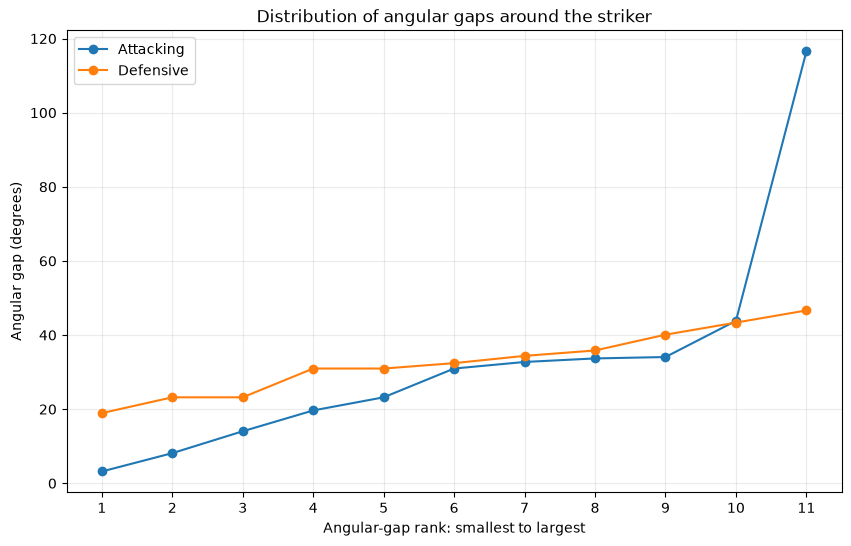

In [26]:
# Compare the angular gaps in the attacking and defensive fields.
#
# The player pairs are different in the two settings, so rather than trying
# to match individual gaps directly, rank the gaps from smallest to largest.
# This lets us compare how concentrated or evenly distributed the angular
# spacing is in each field.

attacking_gap_values = (
    attacking_gaps["angular_gap_deg"]
    .sort_values()
    .reset_index(drop=True)
)

defensive_gap_values = (
    defensive_gaps["angular_gap_deg"]
    .sort_values()
    .reset_index(drop=True)
)

# Each complete XI produces 11 angular gaps around the full circle.
gap_ranks = np.arange(1, len(attacking_gap_values) + 1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    gap_ranks,
    attacking_gap_values,
    marker="o",
    label="Attacking",
)

ax.plot(
    gap_ranks,
    defensive_gap_values,
    marker="o",
    label="Defensive",
)

ax.set_xticks(gap_ranks)
ax.set_xlabel("Angular-gap rank: smallest to largest")
ax.set_ylabel("Angular gap (degrees)")
ax.set_title("Distribution of angular gaps around the striker")

ax.legend()
ax.grid(alpha=0.25)

plt.show()

## Measuring how unevenly the angles are distributed

Every complete fielding XI contains 11 players.

Because the angular gaps between neighbouring players must together complete a full circle, their total is always:

$$
360^\circ
$$

The mean angular gap is therefore fixed:

$$
\frac{360^\circ}{11}
\approx
32.7^\circ
$$

for any complete fielding XI.

This means that **mean angular gap cannot distinguish one complete field from another**.

What can differ is the **variation in those gaps**.

A field in which players are distributed relatively evenly around the striker will have angular gaps of broadly similar sizes.

A field containing tight concentrations in some directions and large empty sectors elsewhere will contain a mixture of very small and very large gaps.

We can therefore summarise angular unevenness using measures such as:

- the standard deviation of the angular gaps;
- the smallest angular gap;
- the largest angular gap.

The attacking field should have greater angular-gap variation because of the tightly packed slip cordon and the large uncovered sector elsewhere.

The defensive field should have less variation because its players have been distributed more evenly around the striker.

In [27]:
# Summarise how unevenly the players are distributed around the striker.
#
# Mean angular gap is not useful here because every complete XI must sum
# to 360°, giving the same mean gap of 360 / 11 ≈ 32.7°.
#
# Instead, compare the spread of the gaps.

angular_gap_summary = pd.DataFrame(
    {
        "field": ["Attacking", "Defensive"],
        "std_gap_deg": [
            attacking_gaps["angular_gap_deg"].std(ddof=0),
            defensive_gaps["angular_gap_deg"].std(ddof=0),
        ],
        "minimum_gap_deg": [
            attacking_gaps["angular_gap_deg"].min(),
            defensive_gaps["angular_gap_deg"].min(),
        ],
        "maximum_gap_deg": [
            attacking_gaps["angular_gap_deg"].max(),
            defensive_gaps["angular_gap_deg"].max(),
        ],
    }
)

angular_gap_summary.round(1)

,field,std_gap_deg,minimum_gap_deg,maximum_gap_deg
0,Attacking,29.0,3.2,116.5
1,Defensive,8.3,18.9,46.6


## Angular concentration distinguishes the two fields

The angular-gap summary confirms what the polar plots suggested.

For the attacking field, the standard deviation of the angular gaps is:

$$
29.0^\circ
$$

compared with:

$$
8.3^\circ
$$

for the defensive field.

The attacking field also contains a much wider range of angular gaps:

$$
3.2^\circ
\quad \text{to} \quad
116.5^\circ
$$

while the defensive field ranges from:

$$
18.9^\circ
\quad \text{to} \quad
46.6^\circ
$$

This reflects the way the two fields were constructed.

The attacking field concentrates several players in a narrow off-side sector behind the striker, producing very small angular gaps there and a much larger gap elsewhere.

The defensive field distributes its players more evenly around the striker, so its angular gaps are much more similar in size.

This gives us another useful spatial distinction between field settings:

> **A field can be described not only by how deep or widely spaced its players are, but also by how evenly they are distributed around the striker.**

Taken together, radial distance, nearest-neighbour spacing and angular-gap variation describe different aspects of the same field setting.

In [28]:
# Bring the main measurements from the two analyses into one compact table.
#
# Distance and spacing are measured in metres, while angular unevenness
# is measured in degrees. Keeping the units explicit avoids creating a
# misleading combined chart with incompatible scales.

final_comparison = pd.DataFrame(
    {
        "measure": [
            "Mean distance from striker's wicket",
            "Median distance from striker's wicket",
            "Mean nearest-neighbour distance",
            "Median nearest-neighbour distance",
            "Angular-gap standard deviation",
            "Minimum angular gap",
            "Maximum angular gap",
        ],
        "unit": [
            "m",
            "m",
            "m",
            "m",
            "degrees",
            "degrees",
            "degrees",
        ],
        "Attacking": [
            field_comparison.loc[
                field_comparison["field"] == "Attacking",
                "mean_distance_m",
            ].iloc[0],
            field_comparison.loc[
                field_comparison["field"] == "Attacking",
                "median_distance_m",
            ].iloc[0],
            field_comparison.loc[
                field_comparison["field"] == "Attacking",
                "mean_nearest_m",
            ].iloc[0],
            field_comparison.loc[
                field_comparison["field"] == "Attacking",
                "median_nearest_m",
            ].iloc[0],
            angular_gap_summary.loc[
                angular_gap_summary["field"] == "Attacking",
                "std_gap_deg",
            ].iloc[0],
            angular_gap_summary.loc[
                angular_gap_summary["field"] == "Attacking",
                "minimum_gap_deg",
            ].iloc[0],
            angular_gap_summary.loc[
                angular_gap_summary["field"] == "Attacking",
                "maximum_gap_deg",
            ].iloc[0],
        ],
        "Defensive": [
            field_comparison.loc[
                field_comparison["field"] == "Defensive",
                "mean_distance_m",
            ].iloc[0],
            field_comparison.loc[
                field_comparison["field"] == "Defensive",
                "median_distance_m",
            ].iloc[0],
            field_comparison.loc[
                field_comparison["field"] == "Defensive",
                "mean_nearest_m",
            ].iloc[0],
            field_comparison.loc[
                field_comparison["field"] == "Defensive",
                "median_nearest_m",
            ].iloc[0],
            angular_gap_summary.loc[
                angular_gap_summary["field"] == "Defensive",
                "std_gap_deg",
            ].iloc[0],
            angular_gap_summary.loc[
                angular_gap_summary["field"] == "Defensive",
                "minimum_gap_deg",
            ].iloc[0],
            angular_gap_summary.loc[
                angular_gap_summary["field"] == "Defensive",
                "maximum_gap_deg",
            ].iloc[0],
        ],
    }
)

final_comparison.round(1)

,measure,unit,Attacking,Defensive
0,Mean distance from striker's wicket,m,19.2,36.0
1,Median distance from striker's wicket,m,20.1,45.7
2,Mean nearest-neighbour distance,m,10.9,23.0
3,Median nearest-neighbour distance,m,12.7,25.6
4,Angular-gap standard deviation,degrees,29.0,8.3
5,Minimum angular gap,degrees,3.2,18.9
6,Maximum angular gap,degrees,116.5,46.6


## How square is a fielding position?

Angle gives us the direction of a fielder around the striker, but cricket also has a more familiar way of describing that geometry: whether a position is **square**, **in front of square** or **behind square**.

In our coordinate convention:

- $+90^\circ$ is exactly square on the off side;
- $-90^\circ$ is exactly square on the leg side.

We can therefore measure how far a position lies from the square line.

We will define the **square offset** as:

$$
s = |\theta| - 90^\circ
$$

where $\theta$ is the angular position around the striker.

This gives a simple interpretation:

- $s = 0^\circ$ means exactly square;
- $s < 0^\circ$ means in front of square;
- $s > 0^\circ$ means behind square.

For example, a position with a square offset of:

$$
-30^\circ
$$

lies $30^\circ$ in front of square, while:

$$
+30^\circ
$$

lies $30^\circ$ behind square.

This is an analytical measure derived from our coordinate system rather than an official cricket statistic.

It translates the general angular representation into terminology that is more directly meaningful when describing cricket field settings.

In [29]:
# Calculate how far each player lies from the square line.
#
# Our convention is:
#   0° square offset  -> exactly square
#   negative value    -> in front of square
#   positive value    -> behind square
#
# The measure is based on the absolute angular position because
# +90° and -90° are both square, on opposite sides of the field.

field_angles["square_offset_deg"] = (
    field_angles["angle_deg"].abs() - 90
)

# Add a cricket-oriented description of the result.
def describe_square_offset(offset):
    if np.isclose(offset, 0):
        return "Square"
    if offset < 0:
        return "In front of square"
    return "Behind square"


field_angles["square_relation"] = (
    field_angles["square_offset_deg"]
    .apply(describe_square_offset)
)

field_angles[
    [
        "field",
        "position",
        "angle_deg",
        "square_offset_deg",
        "square_relation",
    ]
].round(
    {
        "angle_deg": 1,
        "square_offset_deg": 1,
    }
)

,field,position,angle_deg,square_offset_deg,square_relation
0,Attacking,Bowler,0.0,-90.0,In front of square
1,Attacking,Wicket-keeper,180.0,90.0,Behind square
2,Attacking,First slip,149.0,59.0,Behind square
3,Attacking,Second slip,135.0,45.0,Behind square
4,Attacking,Third slip,126.9,36.9,Behind square
5,Attacking,Gully,123.7,33.7,Behind square
6,Attacking,Point,90.0,0.0,Square
7,Attacking,Cover,57.3,-32.7,In front of square
8,Attacking,Mid-off,23.2,-66.8,In front of square
9,Attacking,Mid-on,-19.7,-70.3,In front of square


## Seeing the square line on the field

The square-offset values are easier to interpret if we draw the **square line** directly on the field.

In our coordinate system, the pitch runs along the $y$ axis.

A line square to the striker therefore runs perpendicular to the pitch through the striker's wicket:

$$
y = 0
$$

Positions on this line are exactly square.

Positions with:

$$
y > 0
$$

are in front of square, towards the bowler's end, while positions with:

$$
y < 0
$$

are behind square.

This also shows that the square-offset angle and our earlier coordinate-region classification are describing the same geometry in different ways.

The coordinate sign tells us simply whether a position is in front of or behind square.

The angular measure goes further by telling us **how far from square** that position lies.

For example, point lies exactly on the square line, while cover is in front of it and gully is behind it.

We can now show that distinction directly on a field diagram.

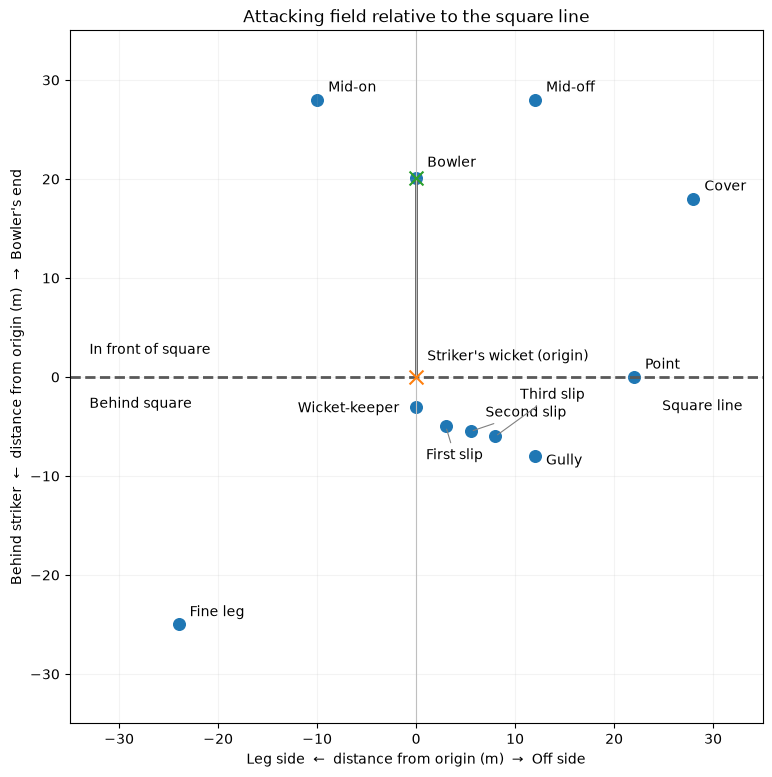

In [30]:
# Plot the attacking field with the square line highlighted.
#
# In our coordinate system:
#   y = 0  -> exactly square
#   y > 0  -> in front of square
#   y < 0  -> behind square

fig, ax = plt.subplots(figsize=(9, 9))

# Plot all 11 players.
ax.scatter(
    attacking_field["x_m"],
    attacking_field["y_m"],
    s=70,
)

# Use the established attacking-field label layout.
standard_label_offsets = {
    "Wicket-keeper": (-12, -4, "right"),
    "Bowler": (8, 8, "left"),
    "Gully": (8, -6, "left"),
    "Point": (8, 6, "left"),
    "Cover": (8, 6, "left"),
    "Mid-off": (8, 6, "left"),
    "Mid-on": (8, 6, "left"),
    "Fine leg": (8, 6, "left"),
}

for _, row in attacking_field.iterrows():
    if row["position"] in standard_label_offsets:
        dx, dy, alignment = standard_label_offsets[row["position"]]

        ax.annotate(
            row["position"],
            (row["x_m"], row["y_m"]),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=alignment,
            fontsize=10,
        )

# Keep the crowded slip-cordon labels separated with leader lines.
slip_labels = {
    "First slip": (1.0, -8.3),
    "Second slip": (7.0, -4.0),
    "Third slip": (10.5, -2.2),
}

for position, (label_x, label_y) in slip_labels.items():
    row = attacking_field[
        attacking_field["position"] == position
    ].iloc[0]

    ax.annotate(
        position,
        xy=(row["x_m"], row["y_m"]),
        xytext=(label_x, label_y),
        textcoords="data",
        fontsize=10,
        ha="left",
        arrowprops={
            "arrowstyle": "-",
            "linewidth": 0.8,
            "color": "0.5",
        },
    )

# Mark the striker's wicket.
ax.scatter(
    0,
    0,
    marker="x",
    s=100,
    zorder=4,
)

ax.annotate(
    "Striker's wicket (origin)",
    (0, 0),
    xytext=(8, 12),
    textcoords="offset points",
    fontsize=10,
)

# Mark the bowler's-end wicket at the same coordinate used for the bowler.
ax.scatter(
    0,
    bowler_wicket_y,
    marker="x",
    s=100,
    zorder=4,
)

# Show the pitch direction between the wickets.
ax.plot(
    [0, 0],
    [0, bowler_wicket_y],
    linewidth=2,
    color="0.35",
)

# Highlight the square line strongly.
ax.axhline(
    0,
    linewidth=2,
    linestyle="--",
    color="0.35",
)

# Place the square-line label below the line at the far right,
# away from Point.
ax.annotate(
    "Square line",
    (33, 0),
    xytext=(0, -16),
    textcoords="offset points",
    ha="right",
    va="top",
    fontsize=10,
)

# Keep the vertical axis visible but visually secondary.
ax.axvline(
    0,
    linewidth=0.8,
    color="0.75",
)

# Add short labels explaining the two halves relative to square.
ax.text(
    -33,
    2,
    "In front of square",
    fontsize=10,
    va="bottom",
)

ax.text(
    -33,
    -2,
    "Behind square",
    fontsize=10,
    va="top",
)

# Preserve real spatial proportions.
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-35, 35)
ax.set_ylim(-35, 35)

ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Attacking field relative to the square line")
ax.grid(alpha=0.15)

plt.show()

## Comparing positions relative to square

The square-offset measure can also be summarised across a complete field setting.

For each player, we now know whether they are:

- in front of square;
- exactly square;
- behind square.

This gives us another cricket-specific way to describe the shape of a field.

The attacking field contains several close catching positions behind square on the off side, particularly the slips and gully.

The defensive field still contains players behind square, but also places more fielders around square and in front of square across both sides of the field.

We can therefore compare the number of players occupying each of these broad relationships to the square line.

As before, the aim is descriptive rather than tactical.

The counts tell us **how the two illustrative fields are arranged relative to square**, not whether one arrangement is preferable.

In [31]:
# Count how many players in each complete field are positioned:
#   - in front of square
#   - exactly square
#   - behind square
#
# This uses the square_relation classification already calculated from
# each player's angular position.

square_counts = (
    field_angles
    .groupby(["field", "square_relation"])
    .size()
    .reset_index(name="players")
)

# Put the categories into a consistent cricket-oriented order.
square_order = [
    "In front of square",
    "Square",
    "Behind square",
]

square_counts["square_relation"] = pd.Categorical(
    square_counts["square_relation"],
    categories=square_order,
    ordered=True,
)

square_counts = square_counts.sort_values(
    ["square_relation", "field"]
)

square_counts

,field,square_relation,players
1,Attacking,In front of square,4
4,Defensive,In front of square,5
2,Attacking,Square,1
5,Defensive,Square,2
0,Attacking,Behind square,6
3,Defensive,Behind square,4


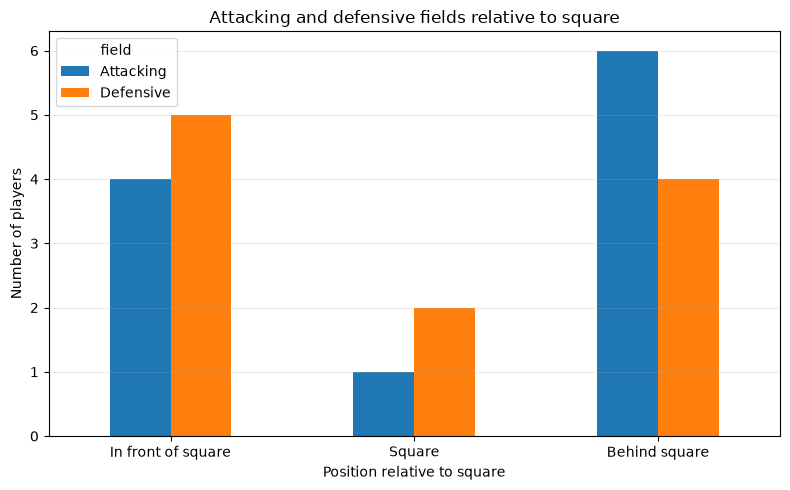

In [32]:
# Compare how the two complete fields distribute players relative to square.

square_plot = (
    square_counts
    .pivot(
        index="square_relation",
        columns="field",
        values="players",
    )
    .reindex(square_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

square_plot.plot(
    kind="bar",
    ax=ax,
)

ax.set_xlabel("Position relative to square")
ax.set_ylabel("Number of players")
ax.set_title("Attacking and defensive fields relative to square")

# Player counts are whole numbers.
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

## What does the square-line comparison add?

The two complete fields also differ in how their players are distributed relative to square.

The attacking field contains:

- **6 players behind square**;
- **4 players in front of square**;
- **1 player exactly square**.

The defensive field contains:

- **4 players behind square**;
- **5 players in front of square**;
- **2 players exactly square**.

The difference is largely produced by the attacking field's slip cordon. First slip, second slip, third slip and gully all occupy positions behind square on the off side.

This is useful because the same spatial difference can now be described in several complementary ways.

The attacking field is:

- shallower overall;
- more tightly spaced locally;
- more unevenly distributed by angle;
- more heavily concentrated behind square.

The defensive field is:

- deeper overall;
- more widely spaced;
- more evenly distributed around the striker;
- less concentrated behind square.

None of these measurements alone defines an attacking or defensive field.

Together, however, they provide a quantitative description of spatial structures that cricket normally expresses through named positions and field-setting terminology.

The square-line analysis also illustrates an important advantage of using coordinates: a generic geometric quantity such as angle can be translated back into a cricket-specific concept such as **square**, **in front of square** and **behind square**.

## Handedness and coordinate orientation

Our horizontal coordinate axis is defined relative to the **striker's off side and leg side**, not relative to a fixed left and right side of the ground.

That distinction matters because the physical off side and leg side reverse for a left-handed striker.

In this study:

- positive $x$ always means the striker's **off side**;
- negative $x$ always means the striker's **leg side**.

For a right-handed striker, this corresponds to the orientation used in our diagrams:

$$
\text{leg side}
\quad \longleftarrow \quad
(0,0)
\quad \longrightarrow \quad
\text{off side}
$$

For a left-handed striker, those sides would occupy the opposite physical sides of the ground.

We do **not** change the meaning of the coordinates.

Instead, the coordinate system remains striker-relative:

$$
+x = \text{off side}
$$

$$
-x = \text{leg side}
$$

This makes the representation useful for comparing field settings across different striker handedness without redefining the spatial measurements themselves.

If the same field were plotted as an absolute map of a particular ground, however, the physical coordinates of off-side and leg-side positions would need to reflect the striker's handedness.

In [33]:
# Classify every player in the two complete fields by broad side.
#
# In our striker-relative coordinate system:
#   x > 0  -> off side
#   x < 0  -> leg side
#   x = 0  -> straight / directly in line with the wickets
#
# Keeping "Straight" separate avoids forcing the bowler and wicket-keeper
# onto either side when they lie on the central axis.

def add_side_classification(field_df, field_name):
    result = field_df.copy()

    result["side"] = result["x_m"].apply(classify_side)
    result["field"] = field_name

    return result


attacking_sides = add_side_classification(
    attacking_field,
    "Attacking",
)

defensive_sides = add_side_classification(
    defensive_field,
    "Defensive",
)

complete_field_sides = pd.concat(
    [
        attacking_sides,
        defensive_sides,
    ],
    ignore_index=True,
)

side_comparison = (
    complete_field_sides
    .groupby(["field", "side"])
    .size()
    .reset_index(name="players")
)

# Keep the categories in a consistent order.
side_order = [
    "Off side",
    "Leg side",
    "Straight",
]

side_comparison["side"] = pd.Categorical(
    side_comparison["side"],
    categories=side_order,
    ordered=True,
)

side_comparison = side_comparison.sort_values(
    ["side", "field"]
)

side_comparison

,field,side,players
1,Attacking,Off side,7
4,Defensive,Off side,5
0,Attacking,Leg side,2
3,Defensive,Leg side,4
2,Attacking,Straight,2
5,Defensive,Straight,2


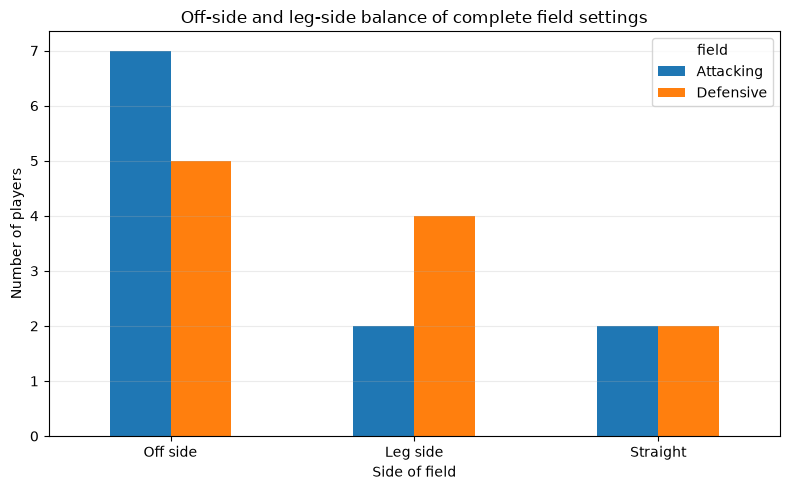

In [34]:
# Compare the off-side / leg-side balance of the two complete fields.

side_plot = (
    side_comparison
    .pivot(
        index="side",
        columns="field",
        values="players",
    )
    .reindex(side_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

side_plot.plot(
    kind="bar",
    ax=ax,
)

ax.set_xlabel("Side of field")
ax.set_ylabel("Number of players")
ax.set_title("Off-side and leg-side balance of complete field settings")

# Player counts are whole numbers.
ax.yaxis.set_major_locator(
    plt.MaxNLocator(integer=True)
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

## Cricket's spatial vocabulary: direction

Cricket already has a rich vocabulary for describing where a fielder stands.

These terms are useful because they describe spatial relationships without requiring coordinates. Our model can make those relationships more explicit.

An important limitation is that most field-position terms do **not** define exact angular sectors. A commentator can describe a fielder as slightly finer, squarer or more backward without crossing a formally defined numerical boundary.

We should therefore treat these words as **relative cricket descriptions**, not convert them into arbitrary fixed degree ranges.

### Square

A fielder is **square** when positioned roughly perpendicular to the line of the pitch from the striker.

In our coordinate system, the square line is:

$$
y = 0
$$

corresponding to approximately:

$$
\theta = +90^\circ
$$

on the off side and:

$$
\theta = -90^\circ
$$

on the leg side.

Examples include **point** and **square leg**.

### In front of square

Moving from the square line towards the bowler's end puts a fielder **in front of square**.

Examples include:

- cover;
- mid-off;
- mid-on;
- midwicket.

In our coordinate system these positions have:

$$
y > 0
$$

### Behind square

Moving from the square line towards the area behind the striker puts a fielder **behind square**.

Examples include:

- backward point;
- gully;
- slips;
- fine leg;
- third man.

In our coordinate system these positions have:

$$
y < 0
$$

### Forward and backward

**Forward** and **backward** modify a position by moving it to either side of the square line.

For example:

- **forward square leg** is on the leg side but in front of square;
- **backward square leg** is on the leg side but behind square;
- **backward point** is point moved behind the square line.

These are relative descriptions rather than fixed angles.

### Straight

A position becomes more **straight** as it moves towards the line of the pitch.

Examples include **mid-off** and **mid-on**, with **long-off** and **long-on** describing deeper positions in broadly the same straight sectors.

### Fine

A position becomes **finer** as it moves away from square towards the direction directly behind the striker.

On the leg side, **fine leg** is therefore finer than square leg.

A captain can also ask a fielder to move **finer** without changing the basic position name.

### Wide

**Wide** generally describes movement away from the straighter line of the pitch.

For example, a **wide mid-off** is positioned farther towards the cover side than a more conventional mid-off.

Again, this is relative terminology rather than a fixed geometrical boundary.

The useful connection to our model is:

$$
\text{cricket direction}
\longleftrightarrow
\text{angular position}
$$

Terms such as **square**, **fine**, **straight**, **forward** and **backward** describe changes that our coordinate system can represent as changes in angle.

The MCC Laws formally define concepts such as *in front of* and *behind*, while the familiar named fielding positions and their modifiers are conventional cricket terminology rather than fixed numerical zones.

Sources: [MCC — Appendix A: Definitions and explanations](https://www.lords.org/mcc/the-laws/appendices) and examples of contemporary field-position terminology in [Cricket Australia match coverage](https://www.cricket.com.au/).

## Cricket's spatial vocabulary: distance

Cricket fielding terminology also describes how far a fielder stands from the striker.

As with the directional terms, these descriptions are usually **relative rather than exact**. Cricket does not define a universal distance at which a position becomes "short", "deep" or "long".

Our coordinate model represents this aspect of field placement using radial distance from the striker's wicket.

### Close

A **close** fielder stands relatively near the striker, usually because the position is intended to create a catching opportunity from an edge, bat-pad contact or similar chance.

The slips and gully are examples of positions that may form part of a close-catching field, although their exact distances vary substantially with bowling type and conditions.

### Silly

The word **silly** identifies exceptionally close catching positions.

Examples include:

- silly point;
- silly mid-off;
- silly mid-on.

These fielders stand much closer to the striker than the ordinary versions of those positions.

The word therefore carries both a spatial and tactical meaning: the position is deliberately very close because a catch from a short reaction distance is being sought.

### Short

**Short** generally means that a fielder has been brought closer to the striker than the usual or deeper version of that position.

Examples include:

- short cover;
- short midwicket;
- short fine leg.

"Short" is therefore a relative modifier. It does not imply one fixed distance in metres.

### Deep

A **deep** position is placed farther from the striker, generally towards the boundary.

Examples include:

- deep point;
- deep cover;
- deep square leg;
- deep midwicket.

Adding **deep** can leave the basic angular direction broadly unchanged while increasing the fielder's distance from the striker.

This is particularly easy to express in our coordinate model:

$$
\text{similar angle}
\quad + \quad
\text{greater distance}
$$

For example, **point** and **deep point** occupy broadly the same directional sector, but deep point has the larger radial distance.

### Long

The term **long** is used in established position names such as:

- long-off;
- long-on.

These are deep positions in the relatively straight off-side and leg-side sectors respectively.

It is better to treat **long-on** and **long-off** as established cricket position names rather than assume that "long" is a general numerical distance category that can be applied mechanically to every position.

### Up and back

Captains and commentators may also describe a fielder as being brought **up** or pushed **back**.

These are relative changes in depth:

- **up** means closer to the striker;
- **back** means farther from the striker.

Unlike changing from square to fine, this can occur without substantially changing the fielder's direction around the striker.

The connection to our spatial model is therefore:

$$
\text{cricket depth}
\longleftrightarrow
\text{distance from the striker}
$$

Terms such as **close**, **silly**, **short**, **deep**, **up** and **back** describe changes that can be represented primarily as changes in radial distance.

This also shows why a fielding position cannot always be described adequately by angle alone.

A complete spatial description needs both:

$$
(\text{distance},\text{angle})
$$

because two fielders can occupy similar directions while standing at very different depths.

## Fielding position names as spatial descriptions

Cricket fielding terminology often combines **direction** and **distance** in a single position name.

That makes many fielding descriptions behave almost like a natural-language coordinate system.

For example:

### Deep backward square leg

This name contains several pieces of spatial information:

- **leg** places the fielder on the striker's leg side;
- **square leg** gives the underlying directional region;
- **backward** moves the position behind the square line;
- **deep** moves the fielder farther from the striker.

In our spatial representation, this corresponds to:

$$
x < 0
$$

and:

$$
y < 0
$$

with a relatively large radial distance from the striker's wicket.

### Deep point

Point is approximately square on the off side.

Adding **deep** changes primarily the distance rather than the direction:

$$
\theta \approx +90^\circ
$$

with a larger value of:

$$
d
$$

than an ordinary point position.

### Backward point

Here the important change is directional.

The fielder remains on the off side but moves behind the square line:

$$
x > 0,\qquad y < 0
$$

The distance from the striker may remain broadly similar.

### Short cover

Cover describes the angular region on the off side in front of square.

Adding **short** moves the fielder closer to the striker while broadly retaining that directional relationship.

### Wide mid-off

Mid-off is a relatively straight off-side position.

Moving **wider** shifts the fielder away from the line of the pitch and towards the cover side.

This changes angle more than depth.

These examples show that field-position descriptions can often be decomposed into several spatial components:

$$
\text{side}
+
\text{direction}
+
\text{depth}
$$

or, in our numerical representation:

$$
(x,y)
\longleftrightarrow
(d,\theta)
$$

Cricket terminology is not a rigid coordinate system. Terms such as **deep**, **backward** and **wide** do not specify exact numbers of metres or degrees.

But they encode genuine spatial relationships.

Understanding those relationships gives us a way to translate tactical descriptions such as:

> "Push deep square leg back and bring point up"

into changes in the underlying geometry of the field.

That connection between cricket language and measurable space is one of the main reasons for constructing the coordinate representation in the first place.

## Translating fielding instructions into spatial changes

Once direction and depth are separated, common fielding instructions can be interpreted as movements through our coordinate system.

Consider four examples.

### Point → deep point

The basic direction remains approximately square on the off side.

The main change is **depth**:

$$
d \uparrow
$$

while the angle remains broadly similar.

### Square leg → backward square leg

The fielder remains on the leg side, but moves from the square line towards the area behind the striker.

The main change is therefore **direction**:

$$
\theta
\rightarrow
\text{farther behind square}
$$

### Mid-off → wide mid-off

The fielder remains in front of square on the off side, but moves farther away from the line of the pitch and towards cover.

Again, this is primarily an angular change rather than a change in depth.

### Cover → short cover

The fielder remains in broadly the same directional sector but moves closer to the striker.

The main change is:

$$
d \downarrow
$$

These distinctions matter when interpreting cricket tactics.

An instruction to move a fielder **back** is not the same spatial change as asking them to move **finer**.

Likewise, moving a fielder **wider** changes a different part of the geometry from bringing them **up**.

We can think of field adjustments as combinations of two basic movements:

$$
\text{change in direction}
\quad+\quad
\text{change in depth}
$$

The exact coordinates of those movements will depend on the real field setting. The important point is that cricket's tactical language can be translated into identifiable changes in spatial structure.

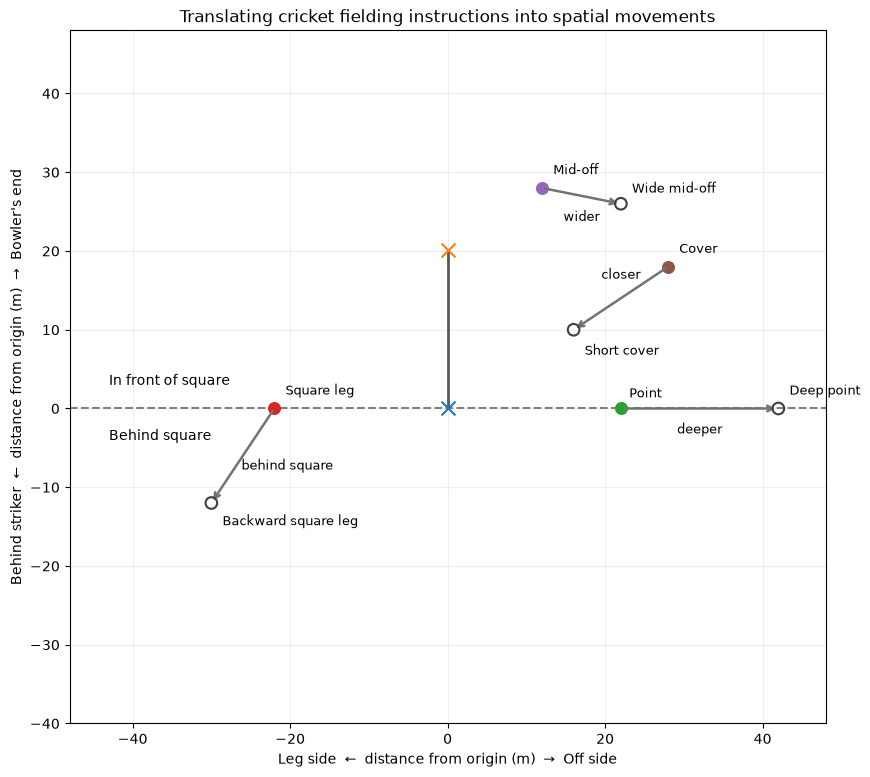

In [35]:
# Visualise four common types of field adjustment.
#
# The start and end coordinates below are illustrative modelling choices.
# They are intended to show the spatial meaning of the terminology, not
# prescribe exact locations for these cricket positions.

field_movements = [
    {
        "from_position": "Point",
        "to_position": "Deep point",
        "x_start": 22,
        "y_start": 0,
        "x_end": 42,
        "y_end": 0,
        "change": "deeper",
    },
    {
        "from_position": "Square leg",
        "to_position": "Backward square leg",
        "x_start": -22,
        "y_start": 0,
        "x_end": -30,
        "y_end": -12,
        "change": "behind square",
    },
    {
        "from_position": "Mid-off",
        "to_position": "Wide mid-off",
        "x_start": 12,
        "y_start": 28,
        "x_end": 22,
        "y_end": 26,
        "change": "wider",
    },
    {
        "from_position": "Cover",
        "to_position": "Short cover",
        "x_start": 28,
        "y_start": 18,
        "x_end": 16,
        "y_end": 10,
        "change": "closer",
    },
]

# Custom text positions keep the movement labels separate.
movement_label_offsets = {
    "Point": {
        "from": (6, 8),
        "to": (8, 10),
        "change": (0, -18),
    },
"Square leg": {
    "from": (8, 10),
    "to": (8, -16),
    "change": (32, -10),
},
    "Mid-off": {
        "from": (8, 10),
        "to": (8, 8),
        "change": (0, -18),
    },
    "Cover": {
        "from": (8, 10),
        "to": (8, -18),
        "change": (0, 14),
    },
}

fig, ax = plt.subplots(figsize=(10, 9))

# Draw the striker's wicket and bowler's-end wicket so that the movements
# retain the same orientation used throughout the study.
ax.scatter(0, 0, marker="x", s=100, zorder=4)
ax.scatter(0, bowler_wicket_y, marker="x", s=100, zorder=4)

ax.plot(
    [0, 0],
    [0, bowler_wicket_y],
    linewidth=2,
    color="0.35",
)

# Draw the square line through the striker's wicket.
ax.axhline(
    0,
    linewidth=1.5,
    linestyle="--",
    color="0.5",
)

# Plot each starting position and draw an arrow towards the adjusted position.
for movement in field_movements:
    x1 = movement["x_start"]
    y1 = movement["y_start"]
    x2 = movement["x_end"]
    y2 = movement["y_end"]

    offsets = movement_label_offsets[movement["from_position"]]

    # Starting position.
    ax.scatter(
        x1,
        y1,
        s=70,
        zorder=3,
    )

    # Arrow showing the fielding adjustment.
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.8,
            "color": "0.45",
        },
    )

    # End position.
    ax.scatter(
        x2,
        y2,
        s=70,
        facecolors="none",
        edgecolors="0.25",
        linewidths=1.5,
        zorder=3,
    )

    # Label the starting position.
    ax.annotate(
        movement["from_position"],
        (x1, y1),
        xytext=offsets["from"],
        textcoords="offset points",
        fontsize=9,
    )

    # Label the adjusted position.
    ax.annotate(
        movement["to_position"],
        (x2, y2),
        xytext=offsets["to"],
        textcoords="offset points",
        fontsize=9,
    )

    # Label the type of spatial change near the middle of the arrow.
    midpoint_x = (x1 + x2) / 2
    midpoint_y = (y1 + y2) / 2

    ax.annotate(
        movement["change"],
        (midpoint_x, midpoint_y),
        xytext=offsets["change"],
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

# Mark the two broad halves relative to square.
ax.text(
    -43,
    3,
    "In front of square",
    fontsize=10,
)

ax.text(
    -43,
    -4,
    "Behind square",
    fontsize=10,
)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-48, 48)
ax.set_ylim(-40, 48)

ax.set_xlabel("Leg side  ←  distance from origin (m)  →  Off side")
ax.set_ylabel("Behind striker  ←  distance from origin (m)  →  Bowler's end")

ax.set_title("Translating cricket fielding instructions into spatial movements")
ax.grid(alpha=0.2)

plt.show()

## Reading tactical field changes spatially

The fielding vocabulary now gives us a way to interpret tactical descriptions more precisely.

Consider instructions such as:

> **"Bring point up."**

Point remains in approximately the same angular direction, but its distance from the striker decreases.

In our representation, this is primarily:

$$
d \downarrow
$$

Now consider:

> **"Push square leg back."**

The main change is again depth:

$$
d \uparrow
$$

while the fielder remains broadly in the square-leg sector.

By contrast:

> **"Move fine leg squarer."**

primarily changes direction. The fielder moves away from the fine-leg direction and towards the square line:

$$
|\theta| \rightarrow 90^\circ
$$

Similarly:

> **"Bring third man finer."**

moves the fielder farther behind the striker and closer to the straight-behind direction:

$$
|\theta| \rightarrow 180^\circ
$$

A captain might also combine both kinds of movement:

> **"Put a deep backward square leg in."**

That description contains information about:

- **side** — leg side;
- **direction** — behind square;
- **depth** — deep.

The coordinate representation therefore gives us a simple way to unpack cricket's tactical language:

$$
\text{fielding instruction}
\rightarrow
\text{change in distance and/or direction}
$$

This does not yet tell us **why** the captain wants that change or whether it will succeed.

Answering those questions would require additional information about the batter, bowler, delivery, scoring areas and match situation.

But we can now understand precisely **what spatial change is being described**.

That is the bridge from representing a cricket field to analysing fielding strategy later.

## Other common spatial language

Cricket also uses several broader terms for groups of fielders rather than individual named positions.

### On side

The **on side** is another term for the **leg side**.

Both terms are used in cricket, so references to an on-side field or an on-side position should be interpreted as referring to the striker's leg side.

### Close catchers

A **close-catching field** contains fielders positioned relatively close to the striker specifically to create catching opportunities.

Slips, gully, silly point and short leg can all form part of close-catching arrangements depending on the bowler and situation.

### Ring fielders

Commentary often refers to fielders **in the ring**.

This broadly describes intermediate fielders positioned closer than the deep outfield, often with the tactical purpose of restricting easy singles.

In limited-overs cricket, this language can also relate to formal fielding-restriction circles, but those rules are format-specific and are outside the scope of this study.

### Deep fielders and boundary riders

Fielders positioned well away from the striker are often described collectively as **deep fielders**.

The informal term **boundary rider** is also used for a fielder positioned deep near the boundary.

These descriptions again refer primarily to depth rather than to one particular angular position.

Together with the named fielding positions, these terms show that cricket describes a field at several spatial levels:

$$
\text{side}
\rightarrow
\text{direction}
\rightarrow
\text{depth}
\rightarrow
\text{named position or fielding group}
$$

Our coordinate representation gives each of those descriptions a common geometric foundation.

## Conclusion

This study began with a simple question:

> **How can a traditional cricket field, described using named positions, be turned into data that can be measured and analysed?**

The first step was to give fielding positions a spatial representation.

Using the centre of the striker's wicket as the origin, we represented player locations as:

$$
(x,y)
$$

with distances measured in metres.

The coordinate system is an analytical convention rather than an official cricket standard, but it is anchored to established cricket terminology and physical dimensions. Positive $x$ always represents the striker's off side, negative $x$ the leg side, and the $y$ axis follows the line of the pitch.

Once the positions were represented numerically, we could measure several different features of a field:

- distance from the striker's wicket;
- direction around the striker;
- off-side and leg-side balance;
- whether a position is square, in front of square or behind square;
- pairwise distances between fielders;
- nearest-neighbour spacing;
- angular gaps between neighbouring directions.

We also saw that traditional cricket terminology already contains a substantial amount of spatial information.

Words such as **square**, **fine**, **straight**, **forward**, **backward** and **wide** primarily describe direction.

Terms such as **close**, **silly**, **short**, **deep**, **up** and **back** primarily describe depth.

Those ideas correspond naturally to the two parts of a polar representation:

$$
\text{fielding position}
\longleftrightarrow
(d,\theta)
$$

where $d$ describes distance from the striker and $\theta$ describes direction around the striker.

More complicated position names can encode several spatial ideas simultaneously.

For example, **deep backward square leg** tells us the side of the field, the underlying directional region, the movement behind square and the greater depth of the position.

Cricket's fielding vocabulary is therefore not a formal coordinate system, but it behaves in many ways like a natural-language description of one.

The same representation also allows fielding instructions to be interpreted geometrically.

Moving **point to deep point** primarily increases distance.

Moving **square leg backward** primarily changes direction.

Moving **fine leg squarer** moves the fielder towards the square line.

Bringing **cover up** reduces distance from the striker.

This gives us a way to translate tactical language into identifiable spatial changes without yet attempting to decide whether those changes are strategically correct.

We then used the representation to compare two deliberately contrasting complete field settings.

The illustrative defensive field was substantially deeper than the attacking field.

Mean distance from the striker's wicket increased from:

$$
19.2\text{ m}
$$

to:

$$
36.0\text{ m}
$$

while median distance increased from:

$$
20.1\text{ m}
$$

to:

$$
45.7\text{ m}
$$

The defensive field was also more widely spaced.

Mean nearest-neighbour distance increased from:

$$
10.9\text{ m}
$$

to:

$$
23.0\text{ m}
$$

and the median increased from:

$$
12.7\text{ m}
$$

to:

$$
25.6\text{ m}
$$

The angular structure revealed another difference.

The attacking field concentrated several players in the narrow sector occupied by the slip cordon. Its angular gaps ranged from:

$$
3.2^\circ
$$

to:

$$
116.5^\circ
$$

with a standard deviation of:

$$
29.0^\circ
$$

The defensive field distributed its players much more evenly around the striker. Its angular gaps ranged from:

$$
18.9^\circ
$$

to:

$$
46.6^\circ
$$

with a standard deviation of only:

$$
8.3^\circ
$$

The fields also differed in recognisably cricket-specific ways.

The attacking field contained:

- **7 players on the off side**;
- **2 players on the leg side**;
- **2 players straight**.

The defensive field contained:

- **5 players on the off side**;
- **4 players on the leg side**;
- **2 players straight**.

Relative to the square line, the attacking field contained:

- **6 players behind square**;
- **4 players in front of square**;
- **1 player exactly square**.

The defensive field contained:

- **4 players behind square**;
- **5 players in front of square**;
- **2 players exactly square**.

The attacking field was therefore not simply "closer" to the striker.

It was simultaneously:

- shallower;
- more locally concentrated;
- more heavily weighted to the off side;
- more concentrated behind square;
- more unevenly distributed around the striker.

The defensive field was:

- deeper;
- more widely spaced;
- more balanced between off side and leg side;
- less concentrated behind square;
- more evenly distributed around the striker.

None of these measurements tells us which field is tactically better.

That would require information about the batter, bowler, delivery, scoring areas, dismissal probabilities and match situation.

What this study establishes is the representation needed to ask those questions.

> **Once a cricket field is represented spatially, traditional field settings and fielding instructions can be translated into measurable changes in distance, direction, spacing and distribution.**

That is the bridge from describing where fielders stand to analysing why they are placed there.

## Limitations and modelling assumptions

This study deliberately uses a simplified representation of cricket fielding positions.

The main limitations are:

- the coordinates assigned to named positions are **illustrative**, not observed player locations;
- named positions such as **cover**, **gully** and **fine leg** describe recognised areas rather than single fixed points;
- modifiers such as **deep**, **short**, **fine**, **wide**, **forward** and **backward** are relative cricket terms rather than universally defined numerical thresholds;
- the bowler is represented schematically at the bowler's end rather than tracked through the delivery and follow-through;
- the wicket-keeper's depth is fixed in the examples even though it varies substantially with bowling type, pace and match situation;
- the attacking and defensive fields were deliberately constructed to produce contrasting spatial structures rather than taken from observed matches;
- no actual ground boundary is included, because cricket grounds do not share one universal boundary size, shape or distance from the striker;
- no formal fielding-restriction circles or format-specific rules are included;
- the model does not include ball trajectory, shot location, scoring probability, dismissal probability or player movement;
- nearest-neighbour distance and angular-gap variation describe spatial structure but should not be interpreted as measures of tactical quality.

The distinction between **relative fielding terminology** and **numerical coordinates** is particularly important.

For example, calling a position **deep** tells us that it is farther from the striker than a shallower version of the same position. It does not imply that cricket defines a particular distance in metres at which "deep" begins.

Likewise, describing a fielder as **finer** or **more backward** indicates a directional change without specifying an exact number of degrees.

These limitations are intentional.

The purpose of Study 19 is not to reproduce a real match or determine an optimal field. It is to establish a transparent spatial representation that can support more realistic analysis later.

A future study could replace the representative coordinates with observed field settings or tracking data while retaining the same basic framework:

$$
\text{player location}
\rightarrow
(x,y)
\rightarrow
\text{distance, angle, spacing and distribution}
$$

That would allow the spatial ideas developed here to be connected to genuine tactical questions.

The key distinction throughout is therefore between **cricket facts**, **cricket terminology** and **modelling choices**.

Where cricket provides established terminology or physical dimensions, we use them.

Where the analysis requires an additional convention, that convention is stated explicitly rather than treated as an official standard.